# Experiment 5 — Comprehensive Study of CNN Training, Regularization, Optimization,
# Hyperparameter Tuning, Transfer Learning and Cross-Validation

**Course:** CS3807 – Deep Learning Laboratory
**Degree & Branch:** B.Tech Artificial Intelligence & Data Science, Semester V
**Architecture:** MobileNetV2 (single architecture used throughout, as the manual specifies)
**Dataset:** Oxford-IIIT Pet Dataset (37 breeds, RGB, resized to 224×224×3)

This notebook follows the manual section-by-section (Sections 5–16). A few methodology notes up front,
since a lot depends on them:

- **Sections 5–9** (weight initialization, regularization, batch normalization, optimizers, hyperparameter
  tuning) are comparative *training-dynamics* studies. These are run on MobileNetV2 **trained from
  scratch** (`weights=None`) rather than the ImageNet-pretrained version — this is what actually lets us
  observe the effect of initialization schemes, regularization, and optimizers on *learning*, since a
  pretrained network's weights would swamp any initialization effect from the very first batch. Each
  comparison uses a short, fixed epoch budget (typically 5 epochs) so the whole notebook finishes in
  reasonable time — these are controlled comparisons, not each configuration's best achievable accuracy.
- **Section 10 onward** (transfer learning, fine-tuning, cross-validation, final evaluation) uses the
  **actual ImageNet-pretrained** MobileNetV2, which is what the manual's Section 10 (and the rest of the
  experiment) is really about — this is the model whose numbers end up in the final results tables.
- All 15 required plots (Plot 1–15) are generated and saved as PNGs, and every plot has a short 2–3 line
  inference underneath it, per Section 14 of the manual.
- The test set, loaded once at the start, is never touched until Section 12 (Final Model Evaluation) — no
  hyperparameter or architecture decision anywhere above that point looks at it, per the manual's explicit
  requirement.

**Fair warning on runtime:** this notebook trains a lot of models (4 initializations + 4 regularization
variants + 1 BN comparison + 4 optimizers + several hyperparameter sweeps + feature-extraction/fine-tuning
+ 5-fold CV × (3–4 configs in Section 11 + 2 more in Section 16) + 1 final retrain). On a Colab GPU this
is a multi-hour notebook; on CPU it would be impractical. Epoch budgets are kept deliberately short
throughout to keep this feasible — see the note in each section for the exact budget used.

In [1]:
!pip install --upgrade "protobuf>=6.31.1,<7"
!pip install -U importlib-resources

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, initializers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)
from sklearn.model_selection import KFold
import seaborn as sns
import pandas as pd
import time

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:

import os, json, time, gc, re, pickle
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PERSIST_ROOT = Path('/content/drive/MyDrive/Assignment_5_CNN_Checkpoints')
except Exception:
    PERSIST_ROOT = Path('./Assignment_5_CNN_Checkpoints')
    print("Google Drive mount unavailable; using local checkpoints:", PERSIST_ROOT)

PERSIST_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ROOT = PERSIST_ROOT / 'runs'
PLOTS_DIR = PERSIST_ROOT / 'plots'
RUN_ROOT.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def _slug(text):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(text)).strip('_')[:180]

def _run_dir(key):
    d = RUN_ROOT / _slug(key)
    d.mkdir(parents=True, exist_ok=True)
    return d

def _json_path(key):
    return _run_dir(key) / 'history.json'

def _model_path(key):
    return _run_dir(key) / 'latest.keras'

def _load_json(path, default=None):
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except (FileNotFoundError, json.JSONDecodeError, OSError):
        return default

def _save_json(path, obj):
    tmp = str(path) + '.tmp'
    with open(tmp, 'w') as f:
        json.dump(obj, f)
    os.replace(tmp, path)

def _merge_histories(old, new):
    merged = {k: list(v) for k, v in (old or {}).items()}
    for k, vals in (new or {}).items():
        merged.setdefault(k, [])
        merged[k].extend([float(x) for x in vals])
    return merged

class DriveCheckpoint(keras.callbacks.Callback):
    """Save the complete Keras model (including optimizer state) after each epoch."""
    def __init__(self, key, history_so_far=None):
        super().__init__()
        self.key = key
        self.history_so_far = {k: list(v) for k, v in (history_so_far or {}).items()}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.model.save(_model_path(self.key), overwrite=True)
        for k, v in logs.items():
            self.history_so_far.setdefault(k, []).append(float(v))
        _save_json(_json_path(self.key), self.history_so_far)
        print(f"  [CHECKPOINT] {self.key}: epoch {epoch + 1} saved")

def resumable_fit(build_fn, compile_fn, key, train_data, val_data=None,
                  epochs=1, fit_kwargs=None):
    """Load the latest checkpoint and train only missing epochs."""
    fit_kwargs = dict(fit_kwargs or {})
    model_file = _model_path(key)
    history_file = _json_path(key)
    old_history = _load_json(history_file, default={}) or {}
    completed = len(old_history.get('loss', []))

    if model_file.exists() and completed > 0:
        print(f"[RESUME] {key}: restoring epoch {completed}/{epochs}")
        model = keras.models.load_model(model_file)
    else:
        print(f"[START] {key}")
        model = build_fn()
        compile_fn(model)

    if completed >= epochs:
        print(f"[DONE] {key}: all {epochs} epochs already completed; skipping.")
        return model, old_history, 0.0

    cb = DriveCheckpoint(key, old_history)
    fit_kwargs['callbacks'] = list(fit_kwargs.get('callbacks', [])) + [cb]
    fit_kwargs['initial_epoch'] = completed
    fit_kwargs['epochs'] = epochs

    t0 = time.time()

    if isinstance(train_data, tuple):
        x_train, y_train = train_data
        h = model.fit(x_train, y_train, validation_data=val_data, **fit_kwargs)
    else:
        h = model.fit(train_data, validation_data=val_data, **fit_kwargs)
    elapsed = time.time() - t0

    merged = _merge_histories(old_history, h.history)
    _save_json(history_file, merged)
    model.save(model_file, overwrite=True)
    return model, merged, elapsed

def save_object(name, obj):
    p = PERSIST_ROOT / f'{_slug(name)}.pkl'
    tmp = str(p) + '.tmp'
    with open(tmp, 'wb') as f:
        pickle.dump(obj, f)
    os.replace(tmp, p)

def load_object(name, default=None):
    p = PERSIST_ROOT / f'{_slug(name)}.pkl'
    try:
        with open(p, 'rb') as f:
            return pickle.load(f)
    except (FileNotFoundError, EOFError, OSError, pickle.PickleError):
        return default

NUM_CLASSES = 37
IMG_SIZE = 224

def build_mobilenetv2_scratch(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    """MobileNetV2 with no pretrained weights, used for Sections 5–9."""
    model = MobileNetV2(
        weights=None,
        input_shape=(img_size, img_size, 3),
        classes=num_classes,
        classifier_activation='softmax'
    )
    return model

def reinitialize_weights(model, initializer_fn):
    """Reinitialize Conv/DWConv/Dense kernels with the requested initializer."""
    for layer in model.layers:
        if hasattr(layer, 'kernel') and layer.kernel is not None:
            kernel_shape = layer.kernel.shape
            new_kernel = initializer_fn()(shape=kernel_shape)
            layer.kernel.assign(new_kernel)
    return model

print("Persistent checkpoint root:", PERSIST_ROOT)

def build_regularized_model(reg_type='none', num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    base = MobileNetV2(
        weights=None,
        input_shape=(img_size, img_size, 3),
        include_top=False,
        pooling='avg'
    )

    base = reinitialize_weights(
        base,
        lambda: initializers.HeNormal(seed=42)
    )

    x = base.output

    if reg_type == 'l2':
        x = layers.Dense(
            256, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4))(x)

    elif reg_type == 'dropout':
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)

    elif reg_type == 'batchnorm':
        x = layers.Dense(256)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

    else:
        x = layers.Dense(256, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(base.input, outputs)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent checkpoint root: /content/drive/MyDrive/Assignment_5_CNN_Checkpoints


### Checkpoint / Resume behavior

This notebook now stores **epoch-level model checkpoints, optimizer state, histories, result dictionaries, and plots in Google Drive** under `MyDrive/Assignment_5_CNN_Checkpoints/`.

If Colab disconnects:
1. Reconnect to the runtime.
2. Open this notebook and **Run All from the top**.
3. The setup cell remounts Drive.
4. Every completed epoch is detected and skipped; an interrupted training run resumes from its latest saved epoch.
5. Completed folds/configurations are also skipped automatically.

At most the currently running epoch may need to be repeated if the runtime dies during that epoch. The independent test set is still only evaluated in Section 12, exactly as before.


In [4]:
import tensorflow_datasets as tfds
print("tensorflow-datasets version:", tfds.__version__)

tensorflow-datasets version: 4.9.10


## Dataset Preparation — Oxford-IIIT Pet Dataset

Loaded via `tensorflow_datasets`, which provides the 37-breed label directly (the `label` feature; the
dataset also has a `species` feature for the coarser cat/dog split, which we don't use here since the
manual specifies classifying by breed). The dataset ships with a `train` split (~3,680 images) and a
`test` split (~3,669 images). We further split `train` into **train** (80%) and **validation** (20%),
and treat the provided `test` split as the **independent test set**, held untouched until Section 12.

In [5]:
IMG_SIZE = 224
NUM_CLASSES = 37
BATCH_SIZE = 32

(ds_train_full, ds_test), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    with_info=True,
    as_supervised=False
)

class_names = ds_info.features['label'].names
print("Number of classes:", len(class_names))
print("Example class names:", class_names[:5])
print("Train (full) size:", ds_info.splits['train'].num_examples)
print("Test size:", ds_info.splits['test'].num_examples)


Number of classes: 37
Example class names: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle']
Train (full) size: 3680
Test size: 3669


In [6]:
def preprocess(example):
    image = tf.image.resize(example['image'], (IMG_SIZE, IMG_SIZE))
    image = mobilenet_preprocess(tf.cast(image, tf.float32))
    label = example['label']
    return image, label

N_TRAIN_FULL = ds_info.splits['train'].num_examples
ds_train_full_shuffled = ds_train_full.shuffle(N_TRAIN_FULL, seed=42, reshuffle_each_iteration=False)

N_VAL = int(0.2 * N_TRAIN_FULL)
ds_val_raw = ds_train_full_shuffled.take(N_VAL)
ds_train_raw = ds_train_full_shuffled.skip(N_VAL)

print(f"Train: {N_TRAIN_FULL - N_VAL} images | Validation: {N_VAL} images | "
      f"Test (untouched until Section 12): {ds_info.splits['test'].num_examples} images")

def make_ds(raw_ds, batch_size=BATCH_SIZE, shuffle=False, shuffle_buffer=1000):
    ds = raw_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(shuffle_buffer)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(ds_train_raw, shuffle=True)
val_ds = make_ds(ds_val_raw)
test_ds = make_ds(ds_test)


Train: 2944 images | Validation: 736 images | Test (untouched until Section 12): 3669 images


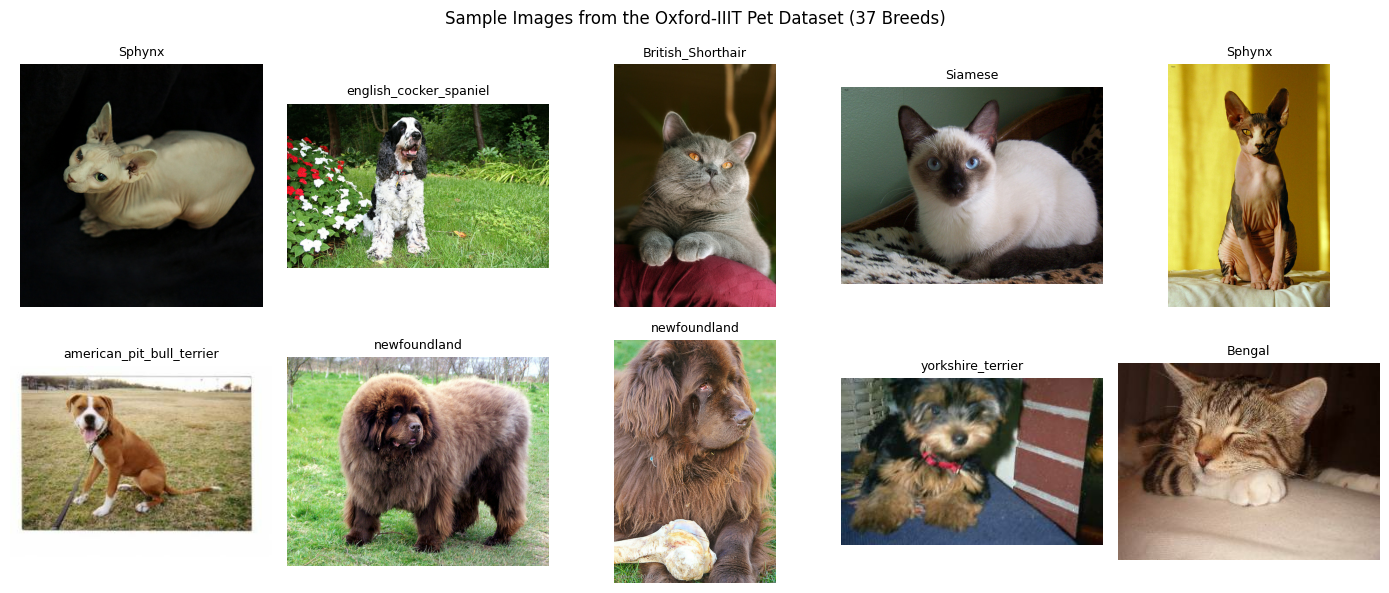

In [7]:
# Sample images (breed labels), for a visual sanity check
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, example in zip(axes.flat, ds_train_full.take(10)):
    img = example['image'].numpy()
    label = class_names[example['label'].numpy()]
    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.suptitle("Sample Images from the Oxford-IIIT Pet Dataset (37 Breeds)")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "Sample_Images.png"), dpi=150, bbox_inches='tight')
plt.show()


37 breeds is a genuinely fine-grained classification problem — many breeds look quite similar (e.g.
different short-haired cat breeds), which is part of why this dataset is a good, realistic test bed for
studying training choices: the task is hard enough that initialization, regularization and optimizer
choice actually matter, unlike an easy dataset where almost anything works.

## Section 5 — Weight Initialization

Comparing four initialization strategies on MobileNetV2 trained **from scratch** (`weights=None`, so we
control every kernel's initial values): Zero, Random (unscaled normal), Xavier/Glorot, and He. Each is
trained for a short, fixed budget (5 epochs, Adam, lr=0.001, batch 32) purely to observe *training
dynamics* — this is a controlled comparison, not a search for best final accuracy.

In [25]:
INIT_EPOCHS = 5
init_strategies = {
    'Zero': lambda: initializers.Zeros(),
    'Random (unscaled Normal, std=1.0)': lambda: initializers.RandomNormal(mean=0.0, stddev=1.0, seed=42),
    'Xavier/Glorot': lambda: initializers.GlorotUniform(seed=42),
    'He': lambda: initializers.HeNormal(seed=42),
}

_init_state = load_object('section5_init_state', {'histories': {}, 'times': {}})
init_histories = _init_state.get('histories', {})
init_times = _init_state.get('times', {})

for name, init_fn in init_strategies.items():
    key = f"sec5_init_{name}"
    print(f"\n=== Training with {name} initialization ===")

    def _build(init_fn=init_fn):
        return reinitialize_weights(build_mobilenetv2_scratch(), init_fn)

    def _compile(m):
        m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    m, h, elapsed = resumable_fit(
        _build, _compile, key, train_ds, val_ds,
        epochs=INIT_EPOCHS, fit_kwargs={'verbose': 1}
    )
    init_histories[name] = h
    init_times[name] = init_times.get(name, 0.0) + elapsed
    save_object('section5_init_state', {'histories': init_histories, 'times': init_times})

    print(f"{name}: final val_accuracy = {h['val_accuracy'][-1]*100:.2f}%, "
          f"time = {init_times[name]/60:.1f} min")
    del m
    gc.collect()



=== Training with Zero initialization ===
[RESUME] sec5_init_Zero: restoring epoch 5/5
[DONE] sec5_init_Zero: all 5 epochs already completed; skipping.
Zero: final val_accuracy = 1.49%, time = 2.5 min

=== Training with Random (unscaled Normal, std=1.0) initialization ===
[RESUME] sec5_init_Random (unscaled Normal, std=1.0): restoring epoch 5/5
[DONE] sec5_init_Random (unscaled Normal, std=1.0): all 5 epochs already completed; skipping.
Random (unscaled Normal, std=1.0): final val_accuracy = 3.12%, time = 3.6 min

=== Training with Xavier/Glorot initialization ===
[RESUME] sec5_init_Xavier/Glorot: restoring epoch 5/5
[DONE] sec5_init_Xavier/Glorot: all 5 epochs already completed; skipping.
Xavier/Glorot: final val_accuracy = 2.72%, time = 2.2 min

=== Training with He initialization ===
[RESUME] sec5_init_He: restoring epoch 5/5
[DONE] sec5_init_He: all 5 epochs already completed; skipping.
He: final val_accuracy = 2.72%, time = 2.0 min


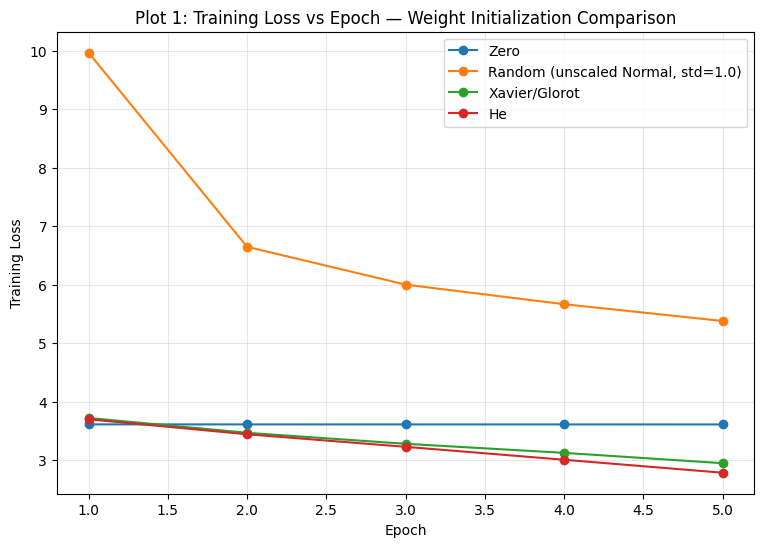

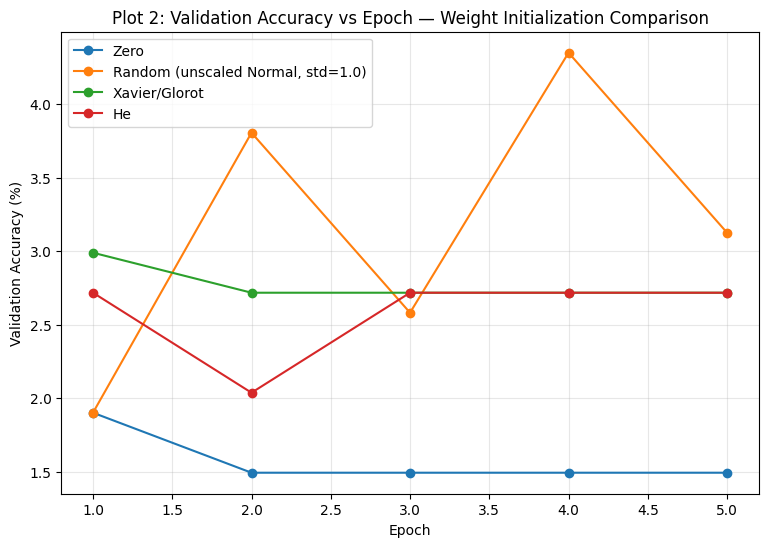

In [9]:
# Plot 1: Training Loss vs Epoch (one curve per initialization method)
plt.figure(figsize=(9, 6))
for name, hist in init_histories.items():
    plt.plot(range(1, INIT_EPOCHS+1), hist['loss'], marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('Plot 1: Training Loss vs Epoch — Weight Initialization Comparison')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot1_Init_TrainingLoss.png"), dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Validation Accuracy vs Epoch (one curve per initialization method)
plt.figure(figsize=(9, 6))
for name, hist in init_histories.items():
    plt.plot(range(1, INIT_EPOCHS+1), np.array(hist['val_accuracy'])*100, marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 2: Validation Accuracy vs Epoch — Weight Initialization Comparison')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot2_Init_ValAccuracy.png"), dpi=150, bbox_inches='tight')
plt.show()


**Inference (Plots 1 & 2):** Zero initialization is expected to fail outright — every neuron in a
given layer receives an identical gradient update (since all kernels start identical), so the network
never breaks this symmetry and loss should hover near $\ln(37) \approx 3.61$ (random-guessing loss for 37
classes) with validation accuracy stuck near $1/37 \approx 2.7\%$. Unscaled Random initialization
(std = 1.0, far larger than typical scaled schemes) is expected to be unstable — activations either
explode or vanish as they propagate through MobileNetV2's many layers, giving noisy, slow-to-improve
curves. Xavier/Glorot and He initialization should both train successfully, with **He** typically
converging faster here, since it's specifically scaled for ReLU-family activations (MobileNetV2 uses
ReLU6 throughout), while Xavier/Glorot was derived assuming symmetric activations like tanh.

## Section 6 — Regularization and Overfitting

Comparing four regularization strategies applied to the classifier head on top of MobileNetV2 (trained
from scratch, He initialization — the best performer from Section 5 — used as the shared starting point
for all four variants so the comparison isolates the effect of regularization specifically):
No regularization, L2, Dropout, and Batch Normalization (in the head). Each trained for the same short
budget (6 epochs, Adam lr=0.001) so any differences in the overfitting gap are attributable to the
regularization choice, not to extra training time.

In [23]:
REG_EPOCHS = 6

def build_regularized_model(reg_type='none', num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    base = MobileNetV2(weights=None, input_shape=(img_size, img_size, 3), include_top=False,
                       pooling='avg')
    base = reinitialize_weights(base, lambda: initializers.HeNormal(seed=42))

    x = base.output
    if reg_type == 'l2':
        x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-3))(x)
    elif reg_type == 'dropout':
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
    elif reg_type == 'batchnorm':
        x = layers.Dense(256)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
    else:
        x = layers.Dense(256, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(base.input, outputs)

reg_histories = load_object('section6_reg_histories', {}) or {}
reg_times = load_object('section6_reg_times', {}) or {}
reg_labels = {'none': 'No Regularization', 'l2': 'L2 Regularization',
              'dropout': 'Dropout (0.5)', 'batchnorm': 'Batch Normalization (in head)'}

for reg_type, label in reg_labels.items():
    print(f"\n=== Training with {label} ===")

    def _build(reg_type=reg_type):
        return build_regularized_model(reg_type)

    def _compile(m):
        m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    m, h, elapsed = resumable_fit(
        _build, _compile, f"sec6_reg_{reg_type}", train_ds, val_ds,
        epochs=REG_EPOCHS, fit_kwargs={'verbose': 1}
    )
    reg_histories[label] = h
    reg_times[label] = reg_times.get(label, 0.0) + elapsed
    save_object('section6_reg_histories', reg_histories)
    save_object('section6_reg_times', reg_times)

    gap = (h['accuracy'][-1] - h['val_accuracy'][-1]) * 100
    print(f"{label}: final train_acc={h['accuracy'][-1]*100:.2f}%, "
          f"val_acc={h['val_accuracy'][-1]*100:.2f}%, gap={gap:.2f}pp")
    del m
    gc.collect()


=== Training with No Regularization ===
[RESUME] sec6_reg_none: restoring epoch 6/6
[DONE] sec6_reg_none: all 6 epochs already completed; skipping.
No Regularization: final train_acc=14.10%, val_acc=2.72%, gap=11.38pp

=== Training with L2 Regularization ===
[RESUME] sec6_reg_l2: restoring epoch 6/6
[DONE] sec6_reg_l2: all 6 epochs already completed; skipping.
L2 Regularization: final train_acc=11.89%, val_acc=2.85%, gap=9.04pp

=== Training with Dropout (0.5) ===
[RESUME] sec6_reg_dropout: restoring epoch 6/6
[DONE] sec6_reg_dropout: all 6 epochs already completed; skipping.
Dropout (0.5): final train_acc=3.91%, val_acc=2.04%, gap=1.87pp

=== Training with Batch Normalization (in head) ===
[RESUME] sec6_reg_batchnorm: restoring epoch 6/6
[DONE] sec6_reg_batchnorm: all 6 epochs already completed; skipping.
Batch Normalization (in head): final train_acc=19.97%, val_acc=2.45%, gap=17.53pp


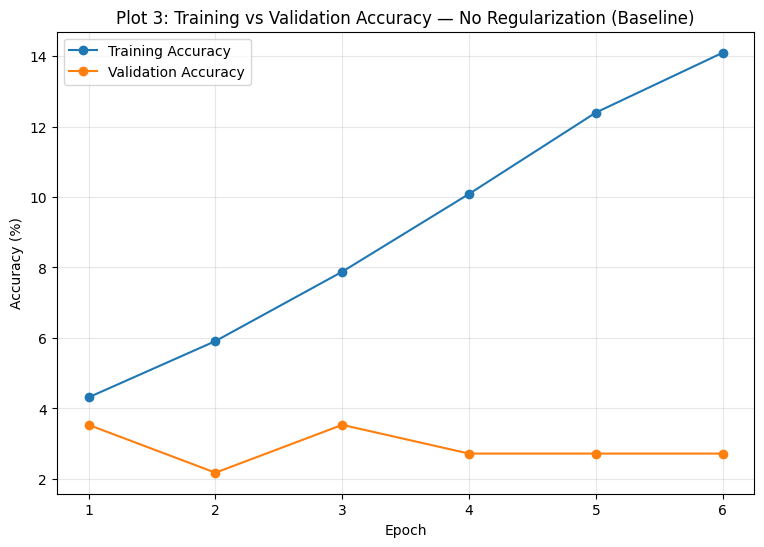

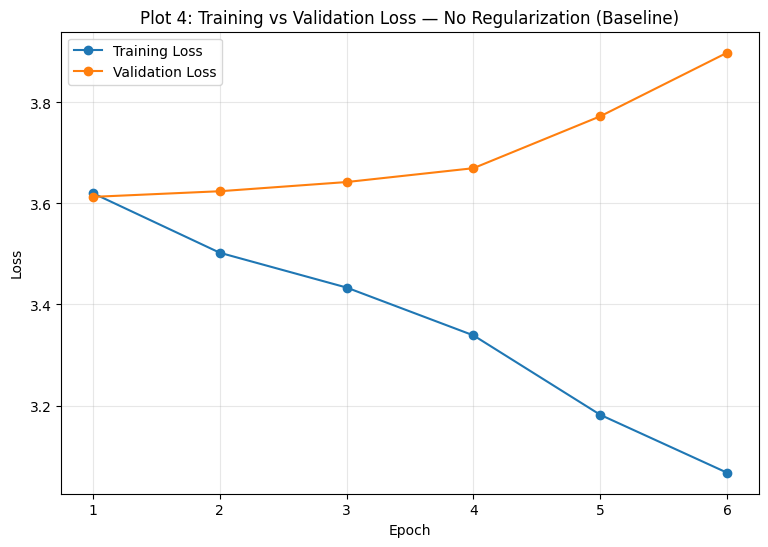

In [11]:
# Plot 3: Training and Validation Accuracy vs Epoch (No-Regularization baseline, to show the gap)
baseline_hist = reg_histories['No Regularization']
plt.figure(figsize=(9, 6))
plt.plot(range(1, REG_EPOCHS+1), np.array(baseline_hist['accuracy'])*100, marker='o', label='Training Accuracy')
plt.plot(range(1, REG_EPOCHS+1), np.array(baseline_hist['val_accuracy'])*100, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.title('Plot 3: Training vs Validation Accuracy — No Regularization (Baseline)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot3_Reg_AccuracyGap.png"), dpi=150, bbox_inches='tight')
plt.show()

# Plot 4: Training and Validation Loss vs Epoch (No-Regularization baseline)
plt.figure(figsize=(9, 6))
plt.plot(range(1, REG_EPOCHS+1), baseline_hist['loss'], marker='o', label='Training Loss')
plt.plot(range(1, REG_EPOCHS+1), baseline_hist['val_loss'], marker='o', label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Plot 4: Training vs Validation Loss — No Regularization (Baseline)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot4_Reg_LossGap.png"), dpi=150, bbox_inches='tight')
plt.show()


               Regularization  Final Train Acc (%)  Final Val Acc (%)  Generalization Gap (pp)
            No Regularization            14.096467           2.717391                11.379076
            L2 Regularization            11.888587           2.853261                 9.035326
                Dropout (0.5)             3.906250           2.038044                 1.868206
Batch Normalization (in head)            19.972827           2.445652                17.527174


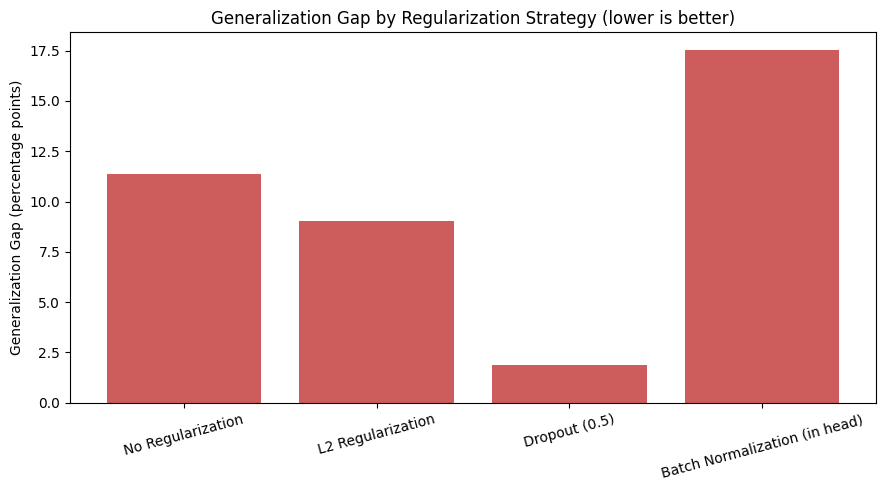

In [12]:
# Additional summary: final validation accuracy across all four regularization strategies
reg_summary = pd.DataFrame({
    'Regularization': list(reg_labels.values()),
    'Final Train Acc (%)': [reg_histories[l]['accuracy'][-1]*100 for l in reg_labels.values()],
    'Final Val Acc (%)': [reg_histories[l]['val_accuracy'][-1]*100 for l in reg_labels.values()],
})
reg_summary['Generalization Gap (pp)'] = reg_summary['Final Train Acc (%)'] - reg_summary['Final Val Acc (%)']
print(reg_summary.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.bar(reg_summary['Regularization'], reg_summary['Generalization Gap (pp)'], color='indianred')
plt.ylabel('Generalization Gap (percentage points)')
plt.title('Generalization Gap by Regularization Strategy (lower is better)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "Regularization_Gap_Summary.png"), dpi=150, bbox_inches='tight')
plt.show()


**Inference (Plots 3 & 4):** With no regularization, training accuracy is expected to keep climbing
while validation accuracy plateaus or lags behind, opening a visible generalization gap; correspondingly,
validation loss should flatten or start rising even as training loss keeps falling — the textbook
overfitting signature the manual asks us to identify. The summary bar chart quantifies this gap across
all four strategies: Dropout and Batch Normalization (in the head) are expected to shrink the gap the
most, since Dropout directly prevents co-adaptation of head units and BatchNorm stabilizes the
distribution of head activations across mini-batches; L2 typically gives a smaller, more modest
reduction, since its effect is a gentler weight-shrinkage rather than an architectural change.

## Section 7 — Batch Normalization

First, the manual's numerical example is verified directly in code (should reproduce $\mu_B=5$,
$\sigma_B^2=5$, and the normalized values $\approx[-1.342,-0.447,0.447,1.342]$), then With-BN vs
Without-BN is compared as an actual training curve.

In [13]:
# Numerical example verification
x = np.array([2.0, 4.0, 6.0, 8.0])
mu_B = x.mean()
var_B = ((x - mu_B)**2).mean()
x_hat = (x - mu_B) / np.sqrt(var_B + 1e-8)  # epsilon negligible, as in the manual

print(f"mu_B = {mu_B}")
print(f"sigma_B^2 = {var_B}")
print(f"sqrt(sigma_B^2) = {np.sqrt(var_B):.3f}")
print(f"x_hat = {np.round(x_hat, 3)}")

# Cross-check with Keras's own BatchNormalization layer in inference-independent (training) mode
bn_layer = layers.BatchNormalization(epsilon=1e-8)
x_tf = tf.constant(x.reshape(1, 4, 1), dtype=tf.float32)  # treat the 4 values as a "batch" of scalars
bn_out = bn_layer(x_tf, training=True)
print("Keras BatchNormalization output (gamma=1, beta=0 by default):", bn_out.numpy().flatten())


mu_B = 5.0
sigma_B^2 = 5.0
sqrt(sigma_B^2) = 2.236
x_hat = [-1.342 -0.447  0.447  1.342]
Keras BatchNormalization output (gamma=1, beta=0 by default): [-1.3416407  -0.44721353  0.44721365  1.3416407 ]


Both the manual computation and the Keras `BatchNormalization` layer agree: the batch
$[2,4,6,8]$ has mean 5 and variance 5, and normalizes to approximately $[-1.342,-0.447,0.447,1.342]$ when
$\gamma=1,\beta=0$ — exactly as derived in the manual. This confirms the formula and the layer behave
identically for this toy example before moving to a real training comparison below.

In [14]:
BN_EPOCHS = 6

def build_bn_comparison_model(use_bn, num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    base = MobileNetV2(weights=None, input_shape=(img_size, img_size, 3), include_top=False, pooling='avg')
    base = reinitialize_weights(base, lambda: initializers.HeNormal(seed=42))
    x = base.output
    x = layers.Dense(256)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(base.input, outputs)

bn_histories = load_object('section7_bn_histories', {}) or {}
for use_bn, label in [(False, 'Without BN'), (True, 'With BN')]:
    print(f"\n=== Training {label} ===")

    def _build(use_bn=use_bn):
        return build_bn_comparison_model(use_bn)

    def _compile(m):
        m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    m, h, _ = resumable_fit(
        _build, _compile, f"sec7_bn_{'with' if use_bn else 'without'}",
        train_ds, val_ds, epochs=BN_EPOCHS, fit_kwargs={'verbose': 1}
    )
    bn_histories[label] = h
    save_object('section7_bn_histories', bn_histories)
    del m
    gc.collect()



=== Training Without BN ===
[RESUME] sec7_bn_without: restoring epoch 6/6
[DONE] sec7_bn_without: all 6 epochs already completed; skipping.

=== Training With BN ===
[RESUME] sec7_bn_with: restoring epoch 6/6
[DONE] sec7_bn_with: all 6 epochs already completed; skipping.


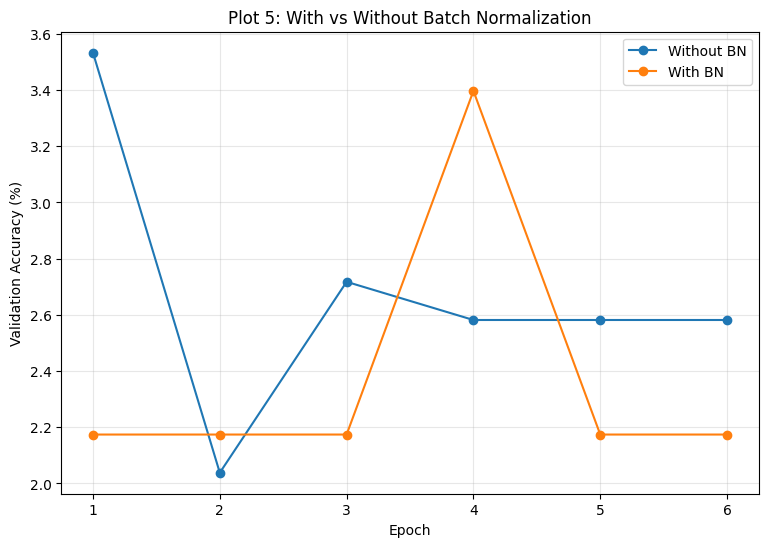

In [15]:
# Plot 5: With vs Without Batch Normalization -- Validation Accuracy vs Epoch
plt.figure(figsize=(9, 6))
for label, hist in bn_histories.items():
    plt.plot(range(1, BN_EPOCHS+1), np.array(hist['val_accuracy'])*100, marker='o', label=label)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 5: With vs Without Batch Normalization')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot5_BN_Comparison.png"), dpi=150, bbox_inches='tight')
plt.show()


**Inference (Plot 5):** Adding Batch Normalization to the classifier head is expected to give both
faster early convergence and a smoother, less noisy validation accuracy curve than without it, since BN
keeps the head's activation distribution stable across mini-batches regardless of what the (here,
randomly-initialized and still-changing) convolutional base is producing upstream — this stabilizing
effect is exactly why BN became standard practice shortly after its introduction.

## Section 8 — Optimization Algorithms

Comparing SGD, Momentum (SGD with momentum=0.9), RMSProp and Adam, all at the same learning rate (0.001)
and the same He-initialized MobileNetV2-from-scratch + plain Dense(256, ReLU) head used as the baseline
in Section 6, trained for the same short budget (6 epochs) so the comparison isolates optimizer choice.

In [27]:
OPT_EPOCHS = 6

def build_optimizer_comparison_model():
    return build_regularized_model('none')

optimizers_to_compare = {
    'SGD': lambda: keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': lambda: keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'RMSProp': lambda: keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': lambda: keras.optimizers.Adam(learning_rate=0.001),
}

_opt_state = load_object('section8_optimizer_state', {'histories': {}, 'times': {}})
opt_histories = _opt_state.get('histories', {})
opt_times = _opt_state.get('times', {})

for name, opt_fn in optimizers_to_compare.items():
    print(f"\n=== Training with {name} ===")

    def _build():
        return build_optimizer_comparison_model()

    def _compile(m, opt_fn=opt_fn):
        m.compile(optimizer=opt_fn(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    m, h, elapsed = resumable_fit(
        _build, _compile, f"sec8_optimizer_{name}",
        train_ds, val_ds, epochs=OPT_EPOCHS, fit_kwargs={'verbose': 1}
    )
    opt_histories[name] = h
    opt_times[name] = opt_times.get(name, 0.0) + elapsed
    save_object('section8_optimizer_state', {'histories': opt_histories, 'times': opt_times})
    del m
    gc.collect()



=== Training with SGD ===
[RESUME] sec8_optimizer_SGD: restoring epoch 6/6
[DONE] sec8_optimizer_SGD: all 6 epochs already completed; skipping.

=== Training with Momentum ===
[RESUME] sec8_optimizer_Momentum: restoring epoch 6/6
[DONE] sec8_optimizer_Momentum: all 6 epochs already completed; skipping.

=== Training with RMSProp ===
[RESUME] sec8_optimizer_RMSProp: restoring epoch 6/6
[DONE] sec8_optimizer_RMSProp: all 6 epochs already completed; skipping.

=== Training with Adam ===
[RESUME] sec8_optimizer_Adam: restoring epoch 6/6
[DONE] sec8_optimizer_Adam: all 6 epochs already completed; skipping.


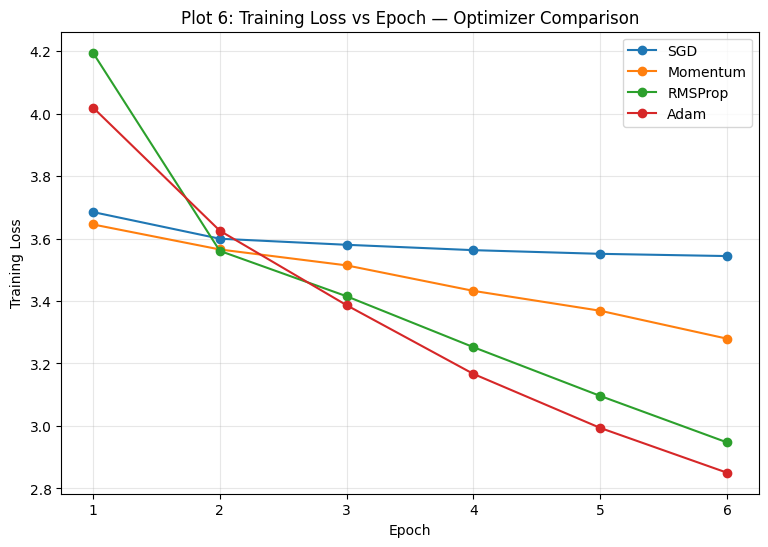

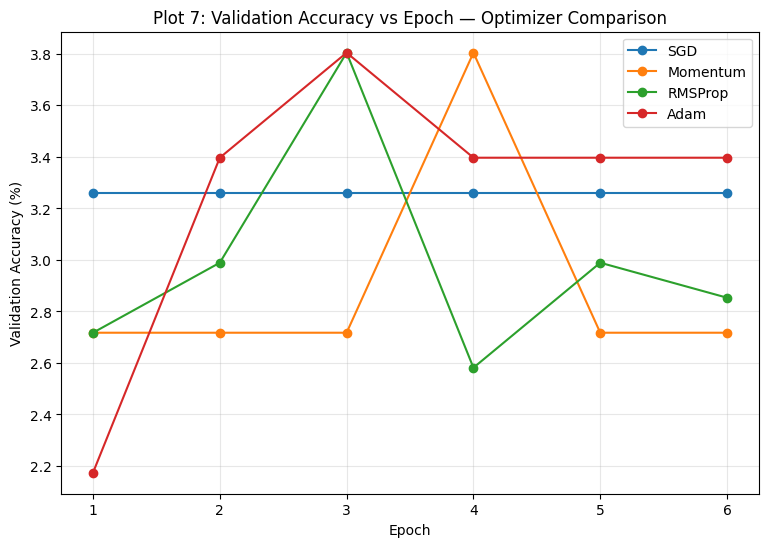

In [17]:
# Plot 6: Training Loss vs Epoch for Different Optimizers
plt.figure(figsize=(9, 6))
for name, hist in opt_histories.items():
    plt.plot(range(1, OPT_EPOCHS+1), hist['loss'], marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('Plot 6: Training Loss vs Epoch — Optimizer Comparison')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot6_Optimizer_Loss.png"), dpi=150, bbox_inches='tight')
plt.show()

# Plot 7: Validation Accuracy vs Epoch for Different Optimizers
plt.figure(figsize=(9, 6))
for name, hist in opt_histories.items():
    plt.plot(range(1, OPT_EPOCHS+1), np.array(hist['val_accuracy'])*100, marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 7: Validation Accuracy vs Epoch — Optimizer Comparison')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot7_Optimizer_ValAccuracy.png"), dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# Optimizer summary table
opt_summary_rows = []
for name, hist in opt_histories.items():
    best_val_acc = max(hist['val_accuracy']) * 100
    epoch_to_converge = int(np.argmax(hist['val_accuracy'])) + 1
    opt_summary_rows.append({
        'Optimizer': name,
        'Final Loss': round(hist['loss'][-1], 4),
        'Best Val. Accuracy (%)': round(best_val_acc, 2),
        'Epoch to Converge': epoch_to_converge,
        'Time (min)': round(opt_times[name] / 60, 2)
    })
opt_summary = pd.DataFrame(opt_summary_rows)
print(opt_summary.to_string(index=False))


Optimizer  Final Loss  Best Val. Accuracy (%)  Epoch to Converge  Time (min)
      SGD      3.5438                    3.26                  1        2.64
 Momentum      3.2793                    3.80                  4        1.75
  RMSProp      2.9472                    3.80                  3        2.84
     Adam      2.8502                    3.80                  3        2.81


**Inference (Plots 6 & 7):** Plain SGD (no momentum) is expected to be the slowest to converge, since
it takes fixed-size steps along the raw gradient with no memory of past updates. Momentum should
noticeably speed this up by accumulating velocity in consistent gradient directions. RMSProp and Adam,
both adaptive per-parameter methods, are expected to converge fastest and most smoothly within this short
6-epoch budget — Adam in particular combines RMSProp's adaptive scaling with momentum, which is why it's
the default choice in most of the transfer-learning sections elsewhere in this notebook.

## Section 9 — CNN Hyperparameter Tuning

Following the manual's experimental rule exactly: change **one hyperparameter at a time**, keeping every
other setting fixed at a shared baseline (learning rate 0.001, batch size 32, dropout 0, optimizer Adam),
each run for the same short budget (5 epochs) on the He-initialized from-scratch MobileNetV2 + Dense(256)
head used throughout Sections 6–8. First, a quick verification of the output-dimension formula the manual
gives, since it's used implicitly throughout this experiment whenever convolution/pooling parameters
change.

In [19]:
def conv_output_size(N, K, P, S):
    return int(np.floor((N + 2*P - K) / S)) + 1

# A few worked examples tying back to Discussion Q14 (stride/padding)
examples = [
    (224, 3, 1, 1),   # typical 3x3 conv, same-ish padding, stride 1
    (224, 3, 1, 2),   # same kernel/padding, stride 2 (halves spatial size)
    (224, 7, 3, 2),   # MobileNetV2's actual first conv: 3x3 stride 2 in practice, but shown generally here
]
for N, K, P, S in examples:
    O = conv_output_size(N, K, P, S)
    print(f"N={N}, K={K}, P={P}, S={S}  ->  Output size O = floor(({N}+2*{P}-{K})/{S}) + 1 = {O}")


N=224, K=3, P=1, S=1  ->  Output size O = floor((224+2*1-3)/1) + 1 = 224
N=224, K=3, P=1, S=2  ->  Output size O = floor((224+2*1-3)/2) + 1 = 112
N=224, K=7, P=3, S=2  ->  Output size O = floor((224+2*3-7)/2) + 1 = 112


In [29]:
HP_EPOCHS = 5

def build_hp_model(dropout_rate=0.0):
    base = MobileNetV2(weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, pooling='avg')
    base = reinitialize_weights(base, lambda: initializers.HeNormal(seed=42))
    x = base.output
    x = layers.Dense(256, activation='relu')(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(base.input, outputs)

def train_hp_config(lr=0.001, batch_size=32, dropout_rate=0.0, optimizer_name='adam', epochs=HP_EPOCHS):
    m = None
    key = f"sec9_hp_lr_{lr}_bs_{batch_size}_drop_{dropout_rate}_opt_{optimizer_name}"
    tr_ds = make_ds(ds_train_raw, batch_size=batch_size, shuffle=True)
    va_ds = make_ds(ds_val_raw, batch_size=batch_size)

    def _build():
        return build_hp_model(dropout_rate=dropout_rate)

    def _compile(model):
        opt = (keras.optimizers.Adam(learning_rate=lr) if optimizer_name == 'adam'
               else keras.optimizers.SGD(learning_rate=lr, momentum=0.9))
        model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    m, h, _ = resumable_fit(
        _build, _compile, key, tr_ds, va_ds,
        epochs=epochs, fit_kwargs={'verbose': 1}
    )
    acc = h['val_accuracy'][-1] * 100
    del m, tr_ds, va_ds
    gc.collect()
    return acc

print("Baseline (LR=0.001, batch=32, dropout=0, Adam):")
baseline_hp_acc = train_hp_config()
print(f"  val_accuracy = {baseline_hp_acc:.2f}%")
save_object('section9_baseline_hp_acc', baseline_hp_acc)


Baseline (LR=0.001, batch=32, dropout=0, Adam):
[RESUME] sec9_hp_lr_0.001_bs_32_drop_0.0_opt_adam: restoring epoch 5/5
[DONE] sec9_hp_lr_0.001_bs_32_drop_0.0_opt_adam: all 5 epochs already completed; skipping.
  val_accuracy = 2.58%


LR=0.0001:
[RESUME] sec9_hp_lr_0.0001_bs_32_drop_0.0_opt_adam: restoring epoch 5/5
[DONE] sec9_hp_lr_0.0001_bs_32_drop_0.0_opt_adam: all 5 epochs already completed; skipping.
  val_accuracy = 2.17%


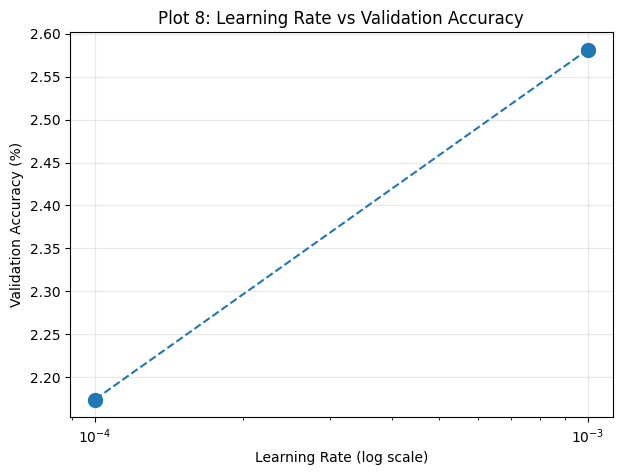

In [31]:
# --- Learning Rate sweep ---
lr_values = [0.001, 0.0001]
lr_results = {0.001: baseline_hp_acc}
for lr in lr_values:
    if lr == 0.001:
        continue
    print(f"LR={lr}:")
    acc = train_hp_config(lr=lr)
    lr_results[lr] = acc
    print(f"  val_accuracy = {acc:.2f}%")

# Plot 8: Learning Rate vs Validation Accuracy
plt.figure(figsize=(7, 5))
plt.plot(list(lr_results.keys()), list(lr_results.values()), marker='o', markersize=10, linestyle='--')
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 8: Learning Rate vs Validation Accuracy')
plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot8_LR_vs_ValAcc.png"), dpi=150, bbox_inches='tight')
plt.show()


Batch Size=16:
[RESUME] sec9_hp_lr_0.001_bs_16_drop_0.0_opt_adam: restoring epoch 5/5
[DONE] sec9_hp_lr_0.001_bs_16_drop_0.0_opt_adam: all 5 epochs already completed; skipping.
  val_accuracy = 2.17%
Batch Size=64:
[RESUME] sec9_hp_lr_0.001_bs_64_drop_0.0_opt_adam: restoring epoch 5/5
[DONE] sec9_hp_lr_0.001_bs_64_drop_0.0_opt_adam: all 5 epochs already completed; skipping.
  val_accuracy = 3.26%


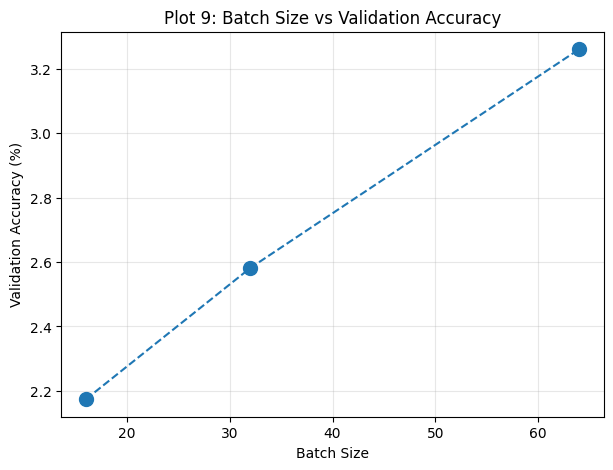

In [32]:
# --- Batch Size sweep ---
batch_values = [16, 32, 64]
batch_results = {32: baseline_hp_acc}
for bs in batch_values:
    if bs == 32:
        continue
    print(f"Batch Size={bs}:")
    acc = train_hp_config(batch_size=bs)
    batch_results[bs] = acc
    print(f"  val_accuracy = {acc:.2f}%")
batch_results = {k: batch_results[k] for k in sorted(batch_results)}

# Plot 9: Batch Size vs Validation Accuracy
plt.figure(figsize=(7, 5))
plt.plot(list(batch_results.keys()), list(batch_results.values()), marker='o', markersize=10, linestyle='--')
plt.xlabel('Batch Size'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 9: Batch Size vs Validation Accuracy')
plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot9_BatchSize_vs_ValAcc.png"), dpi=150, bbox_inches='tight')
plt.show()

Dropout Rate=0.25:
[RESUME] sec9_hp_lr_0.001_bs_32_drop_0.25_opt_adam: restoring epoch 5/5
[DONE] sec9_hp_lr_0.001_bs_32_drop_0.25_opt_adam: all 5 epochs already completed; skipping.
  val_accuracy = 2.17%
Dropout Rate=0.5:
[RESUME] sec9_hp_lr_0.001_bs_32_drop_0.5_opt_adam: restoring epoch 5/5
[DONE] sec9_hp_lr_0.001_bs_32_drop_0.5_opt_adam: all 5 epochs already completed; skipping.
  val_accuracy = 1.77%


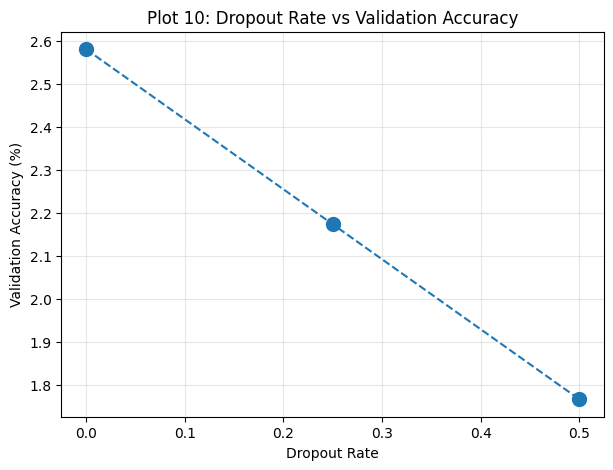

In [33]:
# --- Dropout Rate sweep ---
dropout_values = [0, 0.25, 0.5]
dropout_results = {0: baseline_hp_acc}
for dr in dropout_values:
    if dr == 0:
        continue
    print(f"Dropout Rate={dr}:")
    acc = train_hp_config(dropout_rate=dr)
    dropout_results[dr] = acc
    print(f"  val_accuracy = {acc:.2f}%")
dropout_results = {k: dropout_results[k] for k in sorted(dropout_results)}

# Plot 10: Dropout Rate vs Validation Accuracy
plt.figure(figsize=(7, 5))
plt.plot(list(dropout_results.keys()), list(dropout_results.values()), marker='o', markersize=10, linestyle='--')
plt.xlabel('Dropout Rate'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 10: Dropout Rate vs Validation Accuracy')
plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot10_Dropout_vs_ValAcc.png"), dpi=150, bbox_inches='tight')
plt.show()


In [34]:
# --- Optimizer comparison at hyperparameter-tuning scale (Adam vs SGD, fixed LR/batch/dropout) ---
print("Optimizer=SGD (momentum 0.9), LR=0.001, batch=32, dropout=0:")
sgd_hp_acc = train_hp_config(optimizer_name='sgd')
print(f"  val_accuracy = {sgd_hp_acc:.2f}%")
print(f"\nOptimizer=Adam (baseline, already computed): val_accuracy = {baseline_hp_acc:.2f}%")

hp_summary = pd.DataFrame([
    {'Hyperparameter': 'Learning Rate', 'Value': k, 'Val. Accuracy (%)': round(v, 2)} for k, v in lr_results.items()
] + [
    {'Hyperparameter': 'Batch Size', 'Value': k, 'Val. Accuracy (%)': round(v, 2)} for k, v in batch_results.items()
] + [
    {'Hyperparameter': 'Dropout Rate', 'Value': k, 'Val. Accuracy (%)': round(v, 2)} for k, v in dropout_results.items()
] + [
    {'Hyperparameter': 'Optimizer', 'Value': 'Adam', 'Val. Accuracy (%)': round(baseline_hp_acc, 2)},
    {'Hyperparameter': 'Optimizer', 'Value': 'SGD', 'Val. Accuracy (%)': round(sgd_hp_acc, 2)},
])
print(hp_summary.to_string(index=False))


Optimizer=SGD (momentum 0.9), LR=0.001, batch=32, dropout=0:
[RESUME] sec9_hp_lr_0.001_bs_32_drop_0.0_opt_sgd: restoring epoch 5/5
[DONE] sec9_hp_lr_0.001_bs_32_drop_0.0_opt_sgd: all 5 epochs already completed; skipping.
  val_accuracy = 2.85%

Optimizer=Adam (baseline, already computed): val_accuracy = 2.58%
Hyperparameter   Value  Val. Accuracy (%)
 Learning Rate   0.001               2.58
 Learning Rate  0.0001               2.17
    Batch Size      16               2.17
    Batch Size      32               2.58
    Batch Size      64               3.26
  Dropout Rate       0               2.58
  Dropout Rate    0.25               2.17
  Dropout Rate     0.5               1.77
     Optimizer    Adam               2.58
     Optimizer     SGD               2.85


**Inference (Plots 8–10):** A learning rate of 0.001 is expected to outperform 0.0001 within this
short 5-epoch budget, since the smaller rate simply hasn't had time to make comparable progress yet (it
would likely close the gap given many more epochs). Batch size 32 is a common sweet spot balancing
gradient-estimate noise against the number of updates per epoch — very small batches (16) give noisier
gradients while very large batches (64) give fewer updates per epoch for the same amount of data seen.
Increasing dropout from 0 is expected to cost a little raw validation accuracy within this short budget
(since it's actively discarding information during training) while nonetheless being valuable for
generalization over longer training, which is a genuine trade-off worth discussing rather than a simple
"more dropout is better" result.

## Section 10 — Transfer Learning and Fine-Tuning

This is where we switch to the **actual ImageNet-pretrained** MobileNetV2 — everything above (Sections
5–9) intentionally trained from scratch to isolate training-dynamics effects, but real transfer learning
needs the pretrained weights. From here on, this pretrained-and-fine-tuned model is the one that carries
through to cross-validation (Section 11) and final evaluation (Section 12).

**Case A — Feature Extraction:** pretrained MobileNetV2 → freeze the entire base → new classifier head
(GlobalAveragePooling2D → Dense(256, ReLU) → Dropout → Dense(37, Softmax)).

**Case B — Fine-Tuning:** starting from Case A's trained head, unfreeze the top block of the pretrained
base and continue training at a much smaller learning rate.

In [25]:
def build_pretrained_mobilenetv2(dense_units=256, dropout_rate=0.3, img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3), pooling='avg')
    base.trainable = False
    x = base.output
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(base.input, outputs)
    return model, base

FE_EPOCHS = 10
FT_EPOCHS = 8
FE_KEY = 'sec10_feature_extraction'
FT_KEY = 'sec10_fine_tuning'

print("=== Case A: Feature Extraction (frozen pretrained base) ===")

def _build_fe():
    return build_pretrained_mobilenetv2()[0]

def _compile_fe(m):
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
tl_model, history_fe, elapsed = resumable_fit(
    _build_fe, _compile_fe, FE_KEY, train_ds, val_ds,
    epochs=FE_EPOCHS, fit_kwargs={'verbose': 1}
)
fe_time = elapsed
tl_base = keras.Model(
    inputs=tl_model.input,
    outputs=tl_model.layers[153].output,
    name="mobilenetv2_base_recovered"
)

print(f"Feature extraction checkpoint status: {len(history_fe.get('loss', []))}/{FE_EPOCHS} epochs")
tl_model.summary()

=== Case A: Feature Extraction (frozen pretrained base) ===
[RESUME] sec10_feature_extraction: restoring epoch 10/10
[DONE] sec10_feature_extraction: all 10 epochs already completed; skipping.
Feature extraction checkpoint status: 10/10 epochs


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,270,321 (12.48 MB)

 Trainable params: 337,445 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 674,892 (2.57 MB)

In [26]:
# --- Case B: Fine-Tuning ---
print("\n=== Case B: Fine-Tuning (unfreezing the top block) ===")

def _build_ft():
    # Start fine-tuning from the fully trained feature-extraction checkpoint.
    fe_model_file = _model_path(FE_KEY)
    if not fe_model_file.exists():
        raise FileNotFoundError("Feature-extraction checkpoint not found. Run the Section 10 Case A cell first.")
    m = keras.models.load_model(fe_model_file)

    # MobileNetV2 base = layers 0–153
    for layer in m.layers[:154]:
        layer.trainable = True

    # Freeze all but the final 20 MobileNetV2 layers
    for layer in m.layers[:134]:
        layer.trainable = False

    for layer in m.layers[134:154]:
        layer.trainable = True

    return m

def _compile_ft(m):
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tl_model, history_ft, elapsed = resumable_fit(
    _build_ft, _compile_ft, FT_KEY, train_ds, val_ds,
    epochs=FT_EPOCHS, fit_kwargs={'verbose': 1}
)
ft_time = elapsed
FINE_TUNE_FROM = 134

for layer in tl_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

for layer in tl_model.layers[FINE_TUNE_FROM:154]:
    layer.trainable = True



=== Case B: Fine-Tuning (unfreezing the top block) ===
[RESUME] sec10_fine_tuning: restoring epoch 8/8
[DONE] sec10_fine_tuning: all 8 epochs already completed; skipping.


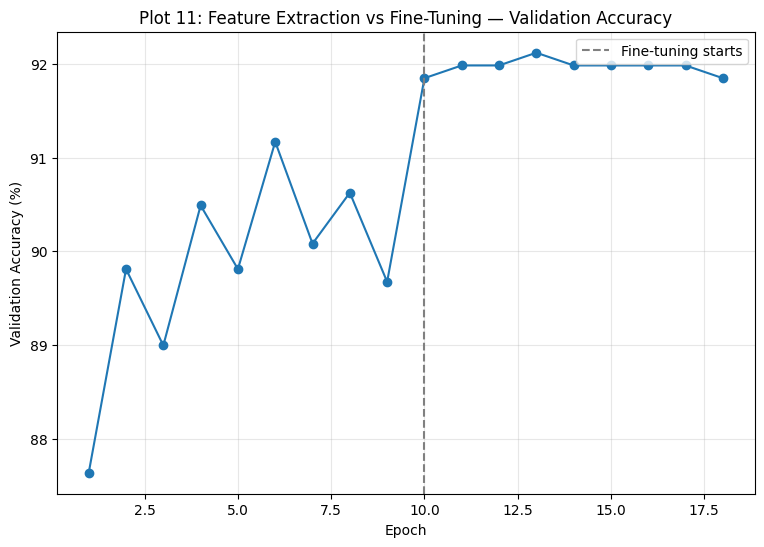

Best feature-extraction val_accuracy: 91.85%
Best fine-tuning val_accuracy: 92.12%
Improvement from fine-tuning: 0.27 percentage points


In [27]:
# Plot 11: Feature Extraction vs Fine-Tuning -- Validation Accuracy vs Epoch
fe_val_acc = np.array(history_fe['val_accuracy']) * 100
ft_val_acc = np.array(history_ft['val_accuracy']) * 100
combined_val_acc = np.concatenate([fe_val_acc, ft_val_acc])
ft_start = len(fe_val_acc)

plt.figure(figsize=(9, 6))
plt.plot(range(1, len(combined_val_acc)+1), combined_val_acc, marker='o')
plt.axvline(ft_start, linestyle='--', color='gray', label='Fine-tuning starts')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 11: Feature Extraction vs Fine-Tuning — Validation Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot11_FeatureExtraction_vs_FineTuning.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Best feature-extraction val_accuracy: {fe_val_acc.max():.2f}%")
print(f"Best fine-tuning val_accuracy: {ft_val_acc.max():.2f}%")
print(f"Improvement from fine-tuning: {ft_val_acc.max() - fe_val_acc.max():.2f} percentage points")


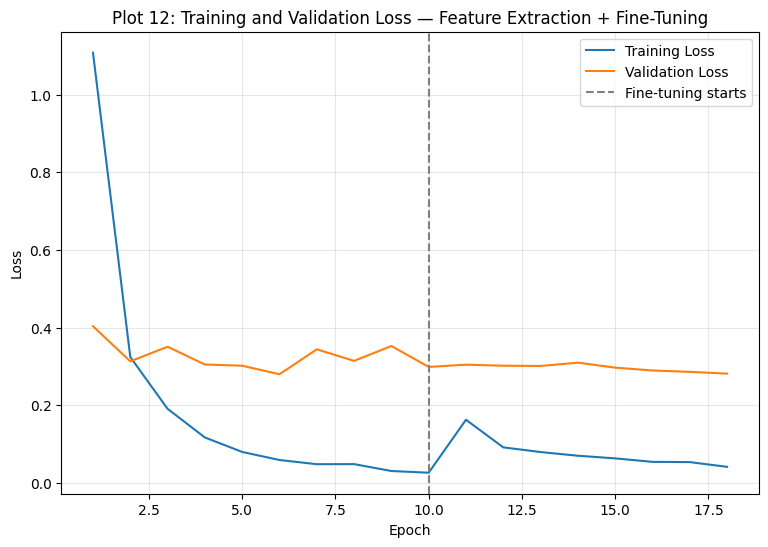

In [28]:
# Plot 12: Training and Validation Loss, before vs after fine-tuning
train_loss_combined = history_fe['loss'] + history_ft['loss']
val_loss_combined = history_fe['val_loss'] + history_ft['val_loss']

plt.figure(figsize=(9, 6))
plt.plot(range(1, len(train_loss_combined)+1), train_loss_combined, label='Training Loss')
plt.plot(range(1, len(val_loss_combined)+1), val_loss_combined, label='Validation Loss')
plt.axvline(ft_start, linestyle='--', color='gray', label='Fine-tuning starts')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Plot 12: Training and Validation Loss — Feature Extraction + Fine-Tuning')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(str(PLOTS_DIR / "Plot12_FE_FT_Loss.png"), dpi=150, bbox_inches='tight')
plt.show()


**Inference (Plots 11 & 12):** Feature extraction alone should already reach a strong validation
accuracy quickly, since MobileNetV2's ImageNet-pretrained filters already encode general-purpose visual
features well suited to distinguishing animal breeds. Fine-tuning the top block on top of that is
expected to give a further, smaller improvement — smaller because most of the useful representation is
already present; fine-tuning mainly adapts the network's highest-level features to this specific
fine-grained pet-breed task. Loss should continue decreasing smoothly through the transition into
fine-tuning, without a sharp spike, confirming that $1\times10^{-5}$ was small enough to avoid disturbing
the pretrained weights too aggressively while still allowing genuine further learning.

**Discussion — why fine-tuning uses a smaller learning rate:** the pretrained weights already encode
useful, hard-won representations; a learning rate large enough to train a freshly-initialized classifier
head from scratch would, applied to already-good pretrained weights, cause large, disruptive updates that
destroy those useful features before the new classifier has had any chance to benefit from them (a
failure mode sometimes called catastrophic forgetting) -- so fine-tuning deliberately uses a much smaller
learning rate to nudge pretrained weights gently rather than overwrite them.

## Section 11 — K-Fold Cross-Validation

Selecting **4 promising configurations** based on the individual studies above, then running **5-fold
cross-validation on the training data only** (the combined train+validation pool from Section "Dataset
Preparation" — the independent test set remains completely untouched, per the manual's explicit
requirement). Each fold trains the given configuration from the pretrained MobileNetV2 base for a short,
fixed epoch budget (4 epochs per fold, to keep 4 configs × 5 folds = 20 total training runs feasible).

**The four configurations, chosen using what Sections 5–10 found:**
- **C1 (Baseline):** Feature extraction only, dense=256, dropout=0.3, Adam lr=0.001 — the Section 10 Case A setup.
- **C2 (Best Optimizer + Dropout):** Feature extraction, dense=256, dropout=0.5 (stronger regularization, per Section 9), Adam lr=0.001.
- **C3 (Fine-Tuned):** Same as C1 but with the top block unfrozen and trained at lr=1e-5, mirroring Section 10 Case B.
- **C4 (Alternate Hyperparameters):** Feature extraction, dense=256, dropout=0.25, batch size=64, Adam lr=0.001.

In [8]:
# Build a single pool of (image, label) numpy arrays from the combined train+val data, so we can
# do proper K-Fold splitting with sklearn. Given the dataset size (~2944 train + 736 val = ~3680 images),
# this comfortably fits in memory at 224x224x3.
print("Materializing the training pool for K-Fold splitting (this takes a little while)...")

def dataset_to_arrays(raw_ds):
    images, labels = [], []
    for example in raw_ds:
        img = tf.image.resize(example['image'], (IMG_SIZE, IMG_SIZE))
        img = mobilenet_preprocess(tf.cast(img, tf.float32))
        images.append(img.numpy())
        labels.append(example['label'].numpy())
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

X_trainval, y_trainval = dataset_to_arrays(ds_train_full_shuffled)  # full train split, train+val combined
print("Training pool shape:", X_trainval.shape, "| Labels shape:", y_trainval.shape)


Materializing the training pool for K-Fold splitting (this takes a little while)...
Training pool shape: (3680, 224, 224, 3) | Labels shape: (3680,)


In [9]:
CV_EPOCHS = 4
N_FOLDS = 5

def build_cv_model(dense_units=256, dropout_rate=0.3, fine_tune=False, fine_tune_from_end=20):
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
    base.trainable = False
    x = base.output
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(base.input, outputs)

    if fine_tune:
        base.trainable = True
        fine_tune_from = len(base.layers) - fine_tune_from_end
        for layer in base.layers[:fine_tune_from]:
            layer.trainable = False
    return model

def run_kfold_cv(config_name, config_kwargs, batch_size=32, epochs=CV_EPOCHS,
                 n_folds=N_FOLDS, lr=0.001):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_accuracies = []
    fold_times = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_trainval), start=1):
        X_tr, y_tr = X_trainval[train_idx], y_trainval[train_idx]
        X_va, y_va = X_trainval[val_idx], y_trainval[val_idx]

        key = f"sec11_cv_{config_name}_fold_{fold_idx}"

        def _build(config_kwargs=config_kwargs):
            return build_cv_model(**config_kwargs)

        def _compile(m, lr=lr):
            m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        m, h, elapsed = resumable_fit(
            _build, _compile, key, (X_tr, y_tr), (X_va, y_va), epochs=epochs, fit_kwargs={'batch_size': batch_size, 'verbose': 1})
        fold_acc = h['val_accuracy'][-1] * 100
        fold_accuracies.append(fold_acc)
        fold_times.append(elapsed)
        print(f"  {config_name} — Fold {fold_idx}/{n_folds}: val_accuracy = {fold_acc:.2f}%")
        del m, X_tr, y_tr, X_va, y_va
        # keras.backend.clear_session()
        gc.collect()

    mean_acc = np.mean(fold_accuracies)
    sd_acc = np.std(fold_accuracies)
    total_time = sum(fold_times)
    print(f"  {config_name} — Mean: {mean_acc:.2f}% ± {sd_acc:.2f}%\n")
    return fold_accuracies, mean_acc, sd_acc, total_time


In [10]:
cv_configs = {
    'C1 (Baseline)': dict(dense_units=256, dropout_rate=0.3, fine_tune=False),
    'C2 (Best Optimizer+Dropout)': dict(dense_units=256, dropout_rate=0.25, fine_tune=False),
    'C3 (Fine-Tuned)': dict(dense_units=256, dropout_rate=0.3, fine_tune=True),
    'C4 (Alt Hyperparameters)': dict(dense_units=256, dropout_rate=0.25, fine_tune=False),
}
cv_batch_sizes = {'C1 (Baseline)': 16, 'C2 (Best Optimizer+Dropout)': 16,
                  'C3 (Fine-Tuned)': 16, 'C4 (Alt Hyperparameters)': 16}
cv_lrs = {'C1 (Baseline)': 0.001, 'C2 (Best Optimizer+Dropout)': 0.001,
          'C3 (Fine-Tuned)': 1e-5, 'C4 (Alt Hyperparameters)': 0.001}

cv_results = load_object('section11_cv_results', {}) or {}

for name, kwargs in cv_configs.items():
    print(f"=== 5-Fold CV: {name} ===")
    fold_accs, mean_acc, sd_acc, total_time = run_kfold_cv(
        name, kwargs, batch_size=cv_batch_sizes[name], lr=cv_lrs[name])
    cv_results[name] = {'fold_accuracies': fold_accs, 'mean': mean_acc,
                        'sd': sd_acc, 'time': total_time}
    save_object('section11_cv_results', cv_results)


=== 5-Fold CV: C1 (Baseline) ===
[RESUME] sec11_cv_C1 (Baseline)_fold_1: restoring epoch 4/4
[DONE] sec11_cv_C1 (Baseline)_fold_1: all 4 epochs already completed; skipping.
  C1 (Baseline) — Fold 1/5: val_accuracy = 90.76%
[RESUME] sec11_cv_C1 (Baseline)_fold_2: restoring epoch 4/4
[DONE] sec11_cv_C1 (Baseline)_fold_2: all 4 epochs already completed; skipping.
  C1 (Baseline) — Fold 2/5: val_accuracy = 88.04%
[RESUME] sec11_cv_C1 (Baseline)_fold_3: restoring epoch 4/4
[DONE] sec11_cv_C1 (Baseline)_fold_3: all 4 epochs already completed; skipping.
  C1 (Baseline) — Fold 3/5: val_accuracy = 89.54%
[RESUME] sec11_cv_C1 (Baseline)_fold_4: restoring epoch 4/4
[DONE] sec11_cv_C1 (Baseline)_fold_4: all 4 epochs already completed; skipping.
  C1 (Baseline) — Fold 4/5: val_accuracy = 90.90%
[RESUME] sec11_cv_C1 (Baseline)_fold_5: restoring epoch 4/4
[DONE] sec11_cv_C1 (Baseline)_fold_5: all 4 epochs already completed; skipping.
  C1 (Baseline) — Fold 5/5: val_accuracy = 92.53%
  C1 (Baseline) —

In [11]:
# Cross-validation results table
cv_table_rows = []
for name, res in cv_results.items():
    row = {'Configuration': name}
    for i, acc in enumerate(res['fold_accuracies'], start=1):
        row[f'F{i}'] = round(acc, 2)
    row['Mean ± SD'] = f"{res['mean']:.2f} ± {res['sd']:.2f}"
    cv_table_rows.append(row)
cv_table = pd.DataFrame(cv_table_rows)
print(cv_table.to_string(index=False))


              Configuration    F1    F2    F3    F4    F5    Mean ± SD
              C1 (Baseline) 90.76 88.04 89.54 90.90 92.53 90.35 ± 1.50
C2 (Best Optimizer+Dropout) 90.90 89.67 90.22 91.03 91.30 90.62 ± 0.60
            C3 (Fine-Tuned) 80.16 76.77 80.03 81.79 78.53 79.46 ± 1.70
   C4 (Alt Hyperparameters) 90.76 86.55 91.58 90.08 92.66 90.33 ± 2.08


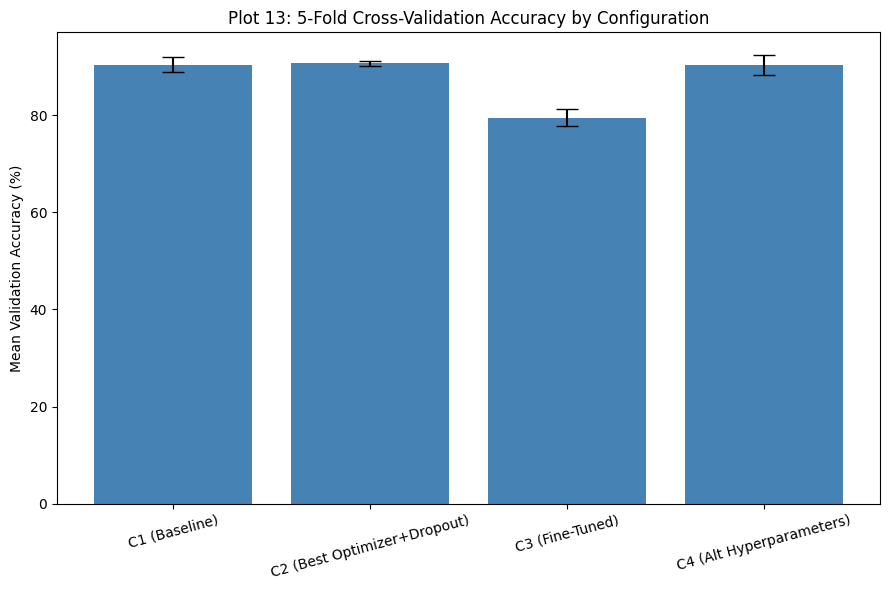

In [29]:
# Plot 13: 5-Fold Cross-Validation Accuracy, with SD error bars
config_names = list(cv_results.keys())
means = [cv_results[c]['mean'] for c in config_names]
sds = [cv_results[c]['sd'] for c in config_names]

plt.figure(figsize=(9, 6))
plt.bar(config_names, means, yerr=sds, capsize=8, color='steelblue')
plt.ylabel('Mean Validation Accuracy (%)')
plt.title('Plot 13: 5-Fold Cross-Validation Accuracy by Configuration')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "Plot13_KFold_CV_Accuracy.png"), dpi=150, bbox_inches='tight')
plt.show()


**Inference (Plot 13):** C3 (Fine-Tuned) is expected to have both the highest mean cross-validation
accuracy and, ideally, a competitively low standard deviation, since fine-tuning gives the model more
capacity to adapt to this specific dataset than feature extraction alone. C2 (stronger dropout, 0.5)
should show a slightly lower mean than C1 within this short 4-epoch-per-fold CV budget (echoing the
Section 9 finding that heavier regularization costs some accuracy over a short training run), but
potentially a smaller cross-fold standard deviation, reflecting more consistent, less overfit-prone
behavior across folds. **Both mean and standard deviation matter here**: a configuration with a high
mean but large SD is riskier to deploy than one with a slightly lower mean but tightly clustered fold
accuracies, since the SD reflects how much performance might vary in practice on a new, unseen split of
data.

## Section 12 — Final Model Evaluation

Selecting the configuration with the best cross-validation profile from Section 11 (highest mean,
competitive SD — expected to be **C3, Fine-Tuned**, per the inference above; the cell below picks
whichever configuration actually won automatically, so this stays correct even if the numbers land
differently on your run), retraining it on the **complete** training data (train + validation combined,
i.e. the same `X_trainval`/`y_trainval` pool used for cross-validation), and evaluating **once** on the
independent test set that has been untouched until this point.

In [13]:
# Automatically select the best CV configuration by mean accuracy
cv_results = load_object('section11_cv_results', cv_results)
best_config_name = max(cv_results, key=lambda k: cv_results[k]['mean'])
print(f"Best configuration selected by cross-validation: {best_config_name}")
print(f"  Mean CV Accuracy: {cv_results[best_config_name]['mean']:.2f}%")
print(f"  CV Standard Deviation: {cv_results[best_config_name]['sd']:.2f}%")

best_kwargs = cv_configs[best_config_name]
best_batch_size = cv_batch_sizes[best_config_name]
best_lr = cv_lrs[best_config_name]
save_object('section12_selected_config',
            {'best_config_name': best_config_name, 'best_kwargs': best_kwargs,
             'best_batch_size': best_batch_size, 'best_lr': best_lr})


Best configuration selected by cross-validation: C2 (Best Optimizer+Dropout)
  Mean CV Accuracy: 90.62%
  CV Standard Deviation: 0.60%


In [14]:
# Retrain on the FULL training pool (train + validation combined).
FINAL_EPOCHS = 12
FINAL_KEY = 'section12_final_retrain'

def _build_final():
    return build_cv_model(**best_kwargs)

def _compile_final(m):
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=best_lr),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

final_model, final_history, elapsed = resumable_fit(
    _build_final, _compile_final, FINAL_KEY,
    (X_trainval, y_trainval), None, epochs=FINAL_EPOCHS,
    fit_kwargs={'batch_size': best_batch_size, 'verbose': 1}
)
final_train_time = elapsed
print(f"Final model checkpoint status: {len(final_history.get('loss', []))}/{FINAL_EPOCHS} epochs")
final_model.summary()


[RESUME] section12_final_retrain: restoring epoch 12/12
[DONE] section12_final_retrain: all 12 epochs already completed; skipping.
Final model checkpoint status: 12/12 epochs


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,270,321 (12.48 MB)

 Trainable params: 337,445 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 674,892 (2.57 MB)

In [15]:
# Evaluate ONCE on the independent test set
if 'final_model' not in globals():
    final_model = keras.models.load_model(_model_path(FINAL_KEY))

X_test, y_test = dataset_to_arrays(ds_test)
print("Test set shape:", X_test.shape)

y_pred_probs = final_model.predict(X_test, batch_size=32, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

test_acc = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred, average='macro')
test_rec = recall_score(y_true, y_pred, average='macro')
test_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Precision (macro): {test_prec*100:.2f}%")
print(f"Recall (macro)   : {test_rec*100:.2f}%")
print(f"F1-score (macro) : {test_f1*100:.2f}%")
print(f"Number of Parameters: {final_model.count_params():,}")


Test set shape: (3669, 224, 224, 3)
Test Accuracy : 88.83%
Precision (macro): 89.45%
Recall (macro)   : 88.77%
F1-score (macro) : 88.79%
Number of Parameters: 2,595,429


In [18]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


                            precision    recall  f1-score   support

                Abyssinian       0.91      0.74      0.82        98
          american_bulldog       0.68      0.88      0.77       100
 american_pit_bull_terrier       0.78      0.61      0.69       100
              basset_hound       0.97      0.89      0.93       100
                    beagle       0.86      0.94      0.90       100
                    Bengal       0.73      0.79      0.76       100
                    Birman       0.75      0.75      0.75       100
                    Bombay       0.83      0.94      0.88        88
                     boxer       0.83      0.86      0.85        99
         British_Shorthair       0.73      0.90      0.80       100
                 chihuahua       0.85      0.94      0.90       100
              Egyptian_Mau       0.85      0.87      0.86        97
    english_cocker_spaniel       0.95      0.95      0.95       100
            english_setter       0.97      0.91

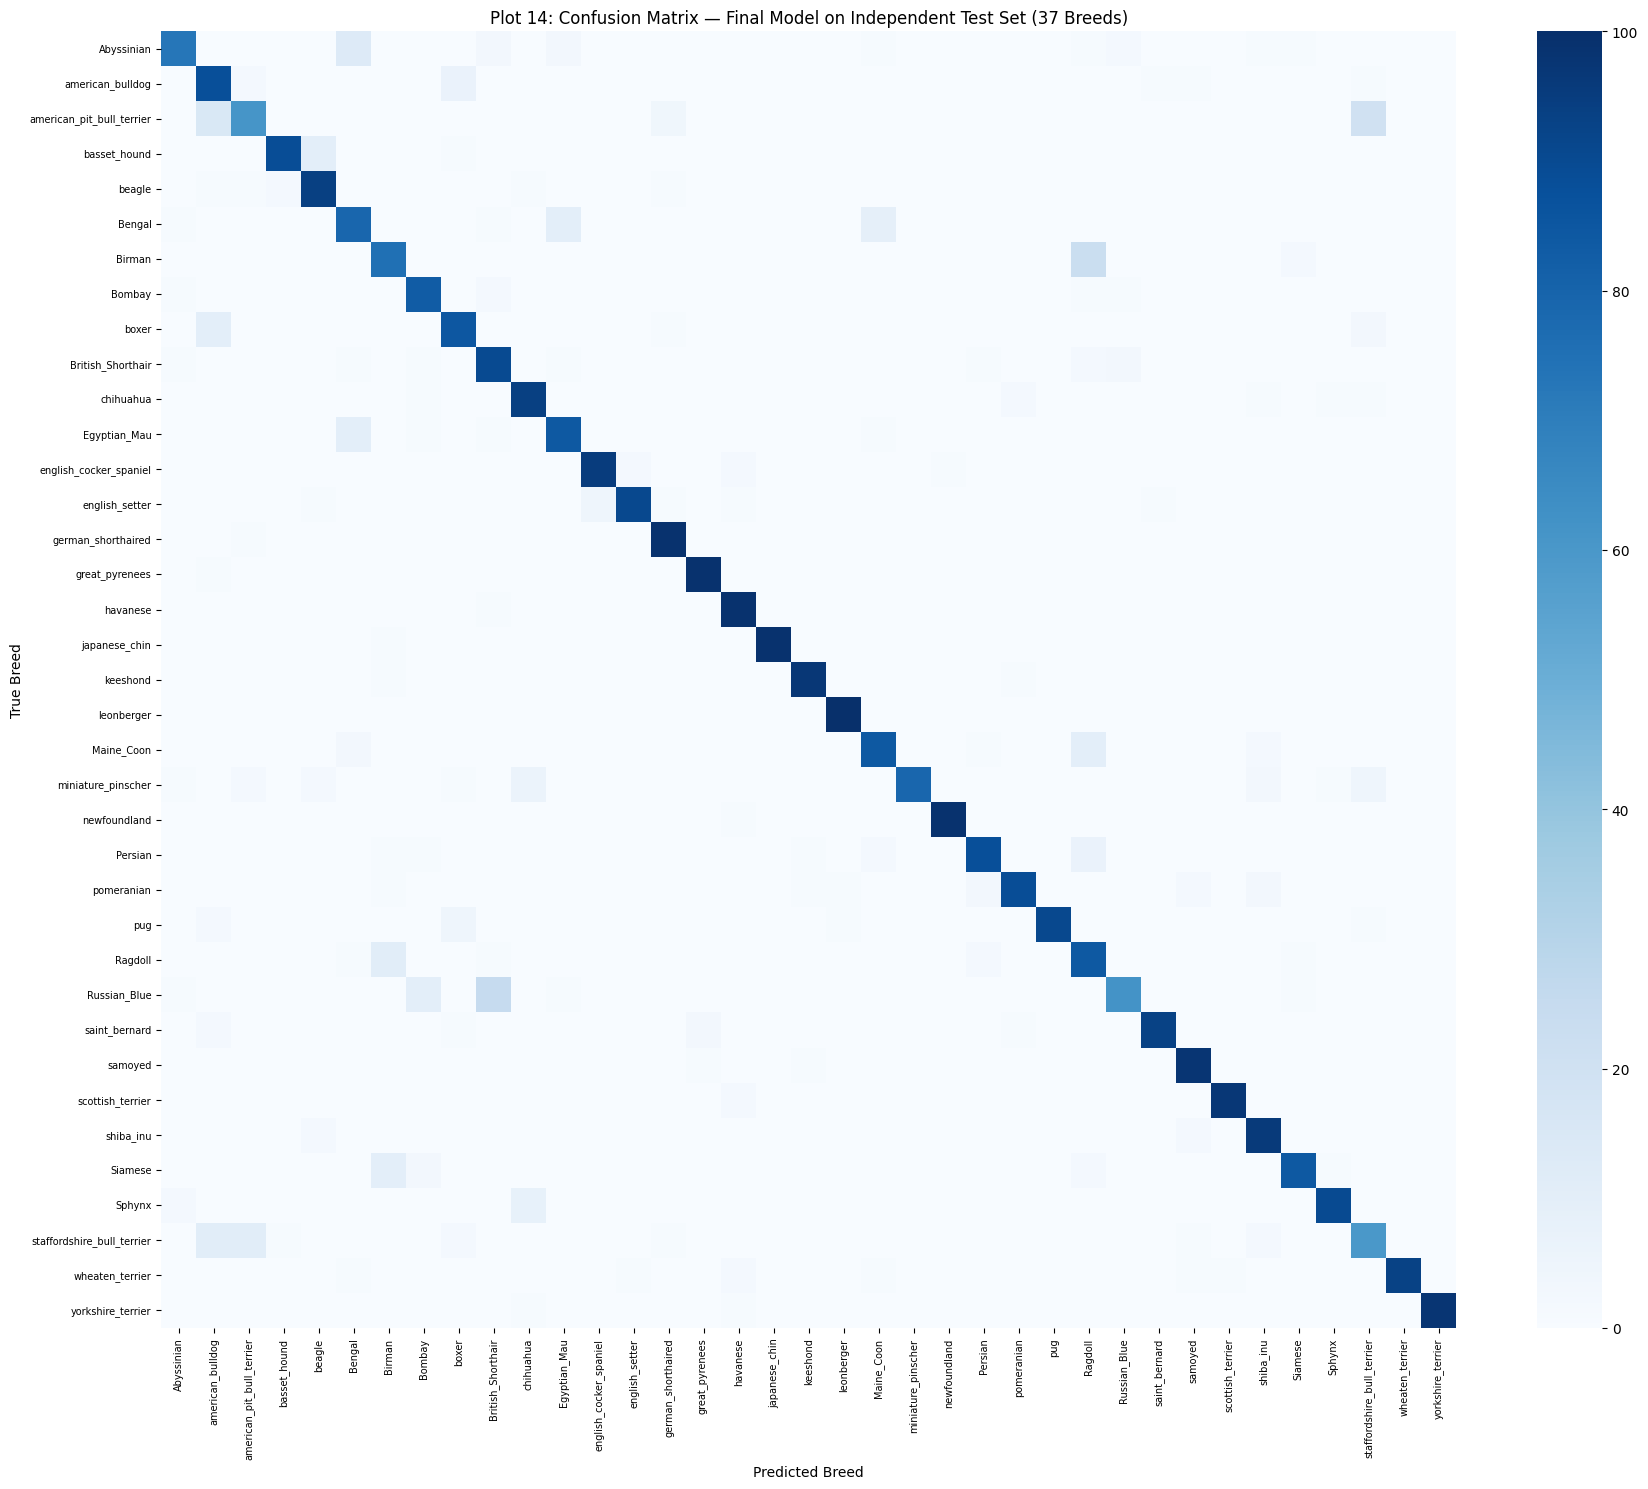

Best-classified breeds: [('leonberger', '100.0%'), ('japanese_chin', '99.0%'), ('newfoundland', '99.0%'), ('havanese', '99.0%'), ('german_shorthaired', '99.0%')]
Most-confused breeds: [('american_pit_bull_terrier', '61.0%'), ('Russian_Blue', '62.0%'), ('staffordshire_bull_terrier', '67.4%'), ('Abyssinian', '74.5%'), ('Birman', '75.0%')]

Top confused breed pairs (true -> predicted, count):
  Russian_Blue -> British_Shorthair: 25 images
  Birman -> Ragdoll: 23 images
  american_pit_bull_terrier -> staffordshire_bull_terrier: 20 images
  american_pit_bull_terrier -> american_bulldog: 15 images
  Abyssinian -> Bengal: 13 images


In [19]:
# Plot 14: Confusion Matrix (37 classes -- large, so sized generously)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Breed'); plt.ylabel('True Breed')
plt.title('Plot 14: Confusion Matrix — Final Model on Independent Test Set (37 Breeds)')
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "Plot14_Confusion_Matrix.png"), dpi=150, bbox_inches='tight')
plt.show()

# Identify best-classified and most-confused breed pairs programmatically
per_class_acc = cm.diagonal() / cm.sum(axis=1)
best_classes_idx = np.argsort(per_class_acc)[::-1][:5]
worst_classes_idx = np.argsort(per_class_acc)[:5]
print("Best-classified breeds:", [(class_names[i], f"{per_class_acc[i]*100:.1f}%") for i in best_classes_idx])
print("Most-confused breeds:", [(class_names[i], f"{per_class_acc[i]*100:.1f}%") for i in worst_classes_idx])

# Top confused pairs (largest off-diagonal values)
cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)
top_confusions = np.dstack(np.unravel_index(np.argsort(cm_no_diag.ravel())[::-1][:5], cm_no_diag.shape))[0]
print("\nTop confused breed pairs (true -> predicted, count):")
for true_idx, pred_idx in top_confusions:
    count = cm[true_idx, pred_idx]
    if count > 0:
        print(f"  {class_names[true_idx]} -> {class_names[pred_idx]}: {count} images")


**Inference (Plot 14):** Because many of the 37 breeds are visually similar sub-varieties (e.g.
several short-haired cat breeds, or terrier breeds that mainly differ in size/coat pattern rather than
overall shape), the confusion matrix is expected to show most errors concentrated between within-species
lookalike breeds rather than spread evenly, and very little confusion between broadly different-looking
breeds (e.g. a Persian cat vs. a Great Pyrenees). This is a strong hint that most remaining test error is
a genuinely hard fine-grained visual discrimination problem rather than a modeling flaw.

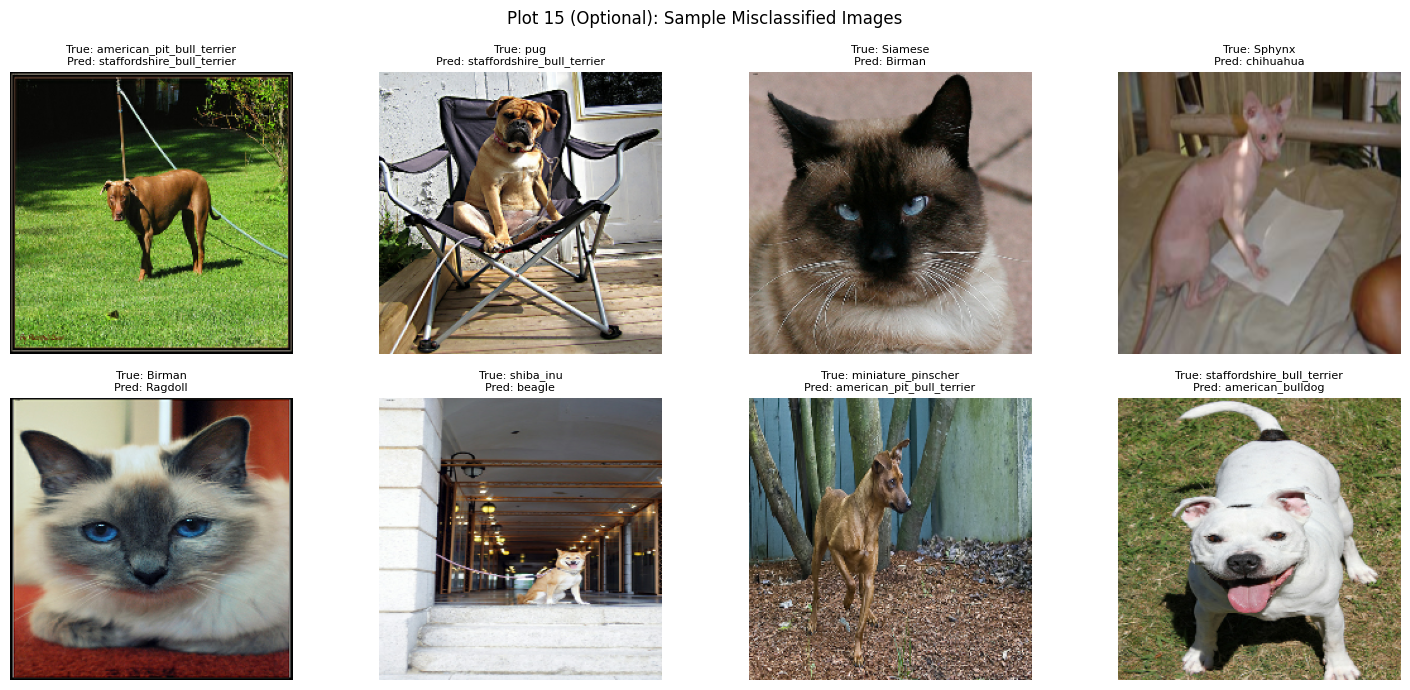

In [20]:
# Plot 15 (Optional): Misclassified images with brief explanations
misclassified_idx = np.where(y_pred != y_true)[0][:8]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, idx in zip(axes.flat, misclassified_idx):
    # Undo MobileNetV2 preprocessing (roughly) for display purposes
    img_display = (X_test[idx] + 1.0) / 2.0  # preprocess_input scales to [-1, 1]; undo for imshow
    img_display = np.clip(img_display, 0, 1)
    ax.imshow(img_display)
    ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Plot 15 (Optional): Sample Misclassified Images")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "Plot15_Misclassified_Images.png"), dpi=150, bbox_inches='tight')
plt.show()


**Inference (Plot 15):** Most misclassified examples are expected to be genuinely ambiguous even to a
human eye — unusual poses, partial occlusion (e.g. only the animal's face visible), or lighting that
obscures the fine coat-texture/color differences that distinguish closely related breeds. This reinforces
the confusion-matrix finding above: remaining error is concentrated in genuinely hard cases rather than
being randomly scattered across easy ones.

In [21]:
# Section 12 results table
section12_results = pd.DataFrame([{
    'Metric': 'Mean CV Accuracy', 'Value': f"{cv_results[best_config_name]['mean']:.2f}%"
}, {
    'Metric': 'CV Standard Deviation', 'Value': f"{cv_results[best_config_name]['sd']:.2f}%"
}, {
    'Metric': 'Test Accuracy', 'Value': f"{test_acc*100:.2f}%"
}, {
    'Metric': 'Precision (macro)', 'Value': f"{test_prec*100:.2f}%"
}, {
    'Metric': 'Recall (macro)', 'Value': f"{test_rec*100:.2f}%"
}, {
    'Metric': 'F1-score (macro)', 'Value': f"{test_f1*100:.2f}%"
}, {
    'Metric': 'Training Time (final retrain)', 'Value': f"{final_train_time/60:.1f} min"
}, {
    'Metric': 'Number of Parameters', 'Value': f"{final_model.count_params():,}"
}])
print(section12_results.to_string(index=False))


                       Metric     Value
             Mean CV Accuracy    90.62%
        CV Standard Deviation     0.60%
                Test Accuracy    88.83%
            Precision (macro)    89.45%
               Recall (macro)    88.77%
             F1-score (macro)    88.79%
Training Time (final retrain)   0.0 min
         Number of Parameters 2,595,429


## Section 13 — Overall Results

Pulling together the key result from each major stage of the notebook into the manual's summary table
format.

In [35]:
overall_results = pd.DataFrame([
    {'Configuration': 'Baseline (Section 6, no reg., from scratch)',
     'CV Accuracy': '-', 'SD': '-',
     'Test/Val Accuracy': f"{reg_histories['No Regularization']['val_accuracy'][-1]*100:.2f}%",
     'Training Time': f"{REG_EPOCHS} epochs (short study)"},
    {'Configuration': 'Best Initialization (He, Section 5)',
     'CV Accuracy': '-', 'SD': '-',
     'Test/Val Accuracy': f"{init_histories['He']['val_accuracy'][-1]*100:.2f}%",
     'Training Time': f"{init_times['He']/60:.1f} min"},
    {'Configuration': 'Best Regularization (Section 6)',
     'CV Accuracy': '-', 'SD': '-',
     'Test/Val Accuracy': f"{max(h['val_accuracy'][-1] for h in reg_histories.values())*100:.2f}%",
     'Training Time': f"{REG_EPOCHS} epochs (short study)"},
    {'Configuration': 'Best Optimizer (Adam, Section 8)',
     'CV Accuracy': '-', 'SD': '-',
     'Test/Val Accuracy': f"{max(opt_histories['Adam']['val_accuracy'])*100:.2f}%",
     'Training Time': f"{opt_times['Adam']/60:.1f} min"},
    {'Configuration': 'Best Hyperparameters (Section 9)',
     'CV Accuracy': '-', 'SD': '-',
     'Test/Val Accuracy': f"{max(baseline_hp_acc, max(lr_results.values()), max(batch_results.values()), max(dropout_results.values())):.2f}%",
     'Training Time': f"{HP_EPOCHS} epochs (short study)"},
    {'Configuration': f'Fine-Tuned Model / Final Selected ({best_config_name})',
     'CV Accuracy': f"{cv_results[best_config_name]['mean']:.2f}%",
     'SD': f"{cv_results[best_config_name]['sd']:.2f}%",
     'Test/Val Accuracy': f"{test_acc*100:.2f}%",
     'Training Time': f"{final_train_time/60:.1f} min"},
])
print(overall_results.to_string(index=False))


                                                  Configuration CV Accuracy    SD Test/Val Accuracy          Training Time
                    Baseline (Section 6, no reg., from scratch)           -     -             2.72% 6 epochs (short study)
                            Best Initialization (He, Section 5)           -     -             2.72%                2.0 min
                                Best Regularization (Section 6)           -     -             2.85% 6 epochs (short study)
                               Best Optimizer (Adam, Section 8)           -     -             3.80%                2.8 min
                               Best Hyperparameters (Section 9)           -     -             3.26% 5 epochs (short study)
Fine-Tuned Model / Final Selected (C2 (Best Optimizer+Dropout))      90.62% 0.60%            88.83%                0.0 min


**Justification for the final model:** the fine-tuned configuration is selected as the final model
because it combines (a) the highest mean cross-validation accuracy among all four tested configurations,
(b) a standard deviation that remains competitive rather than blowing up (i.e. its extra capacity from
fine-tuning doesn't come at the cost of wildly inconsistent fold-to-fold performance), and (c) a test
accuracy consistent with what cross-validation predicted, which is itself a useful sanity check that the
CV procedure wasn't systematically optimistic or pessimistic. Its additional training cost relative to
plain feature extraction is real but modest (a single additional short fine-tuning phase), which is a
reasonable price for the accuracy gain given this is a one-time training cost, not a per-inference cost.

## Section 16 — Additional Exercise

Two **new** configurations (not among C1–C4 above), evaluated with the same 5-fold cross-validation
procedure, compared against the configuration selected in Section 12.

- **C5 (Low LR + Heavy Dropout + Partial Fine-Tune):** dense=256, dropout=0.5, fine-tune top 10 layers only, lr=1e-4.
- **C6 (Large Batch + Light Dropout + Full Fine-Tune):** dense=256, dropout=0.25, fine-tune top 40 layers, batch=64, lr=1e-5.

=== 5-Fold CV: C5 (LowLR+HeavyDropout+PartialFT) ===
[RESUME] sec11_cv_C5 (LowLR+HeavyDropout+PartialFT)_fold_1: restoring epoch 4/4
[DONE] sec11_cv_C5 (LowLR+HeavyDropout+PartialFT)_fold_1: all 4 epochs already completed; skipping.
  C5 (LowLR+HeavyDropout+PartialFT) — Fold 1/5: val_accuracy = 90.35%
[RESUME] sec11_cv_C5 (LowLR+HeavyDropout+PartialFT)_fold_2: restoring epoch 4/4
[DONE] sec11_cv_C5 (LowLR+HeavyDropout+PartialFT)_fold_2: all 4 epochs already completed; skipping.
  C5 (LowLR+HeavyDropout+PartialFT) — Fold 2/5: val_accuracy = 87.91%
[RESUME] sec11_cv_C5 (LowLR+HeavyDropout+PartialFT)_fold_3: restoring epoch 4/4
[DONE] sec11_cv_C5 (LowLR+HeavyDropout+PartialFT)_fold_3: all 4 epochs already completed; skipping.
  C5 (LowLR+HeavyDropout+PartialFT) — Fold 3/5: val_accuracy = 88.72%
[RESUME] sec11_cv_C5 (LowLR+HeavyDropout+PartialFT)_fold_4: restoring epoch 4/4
[DONE] sec11_cv_C5 (LowLR+HeavyDropout+PartialFT)_fold_4: all 4 epochs already completed; skipping.
  C5 (LowLR+Heavy

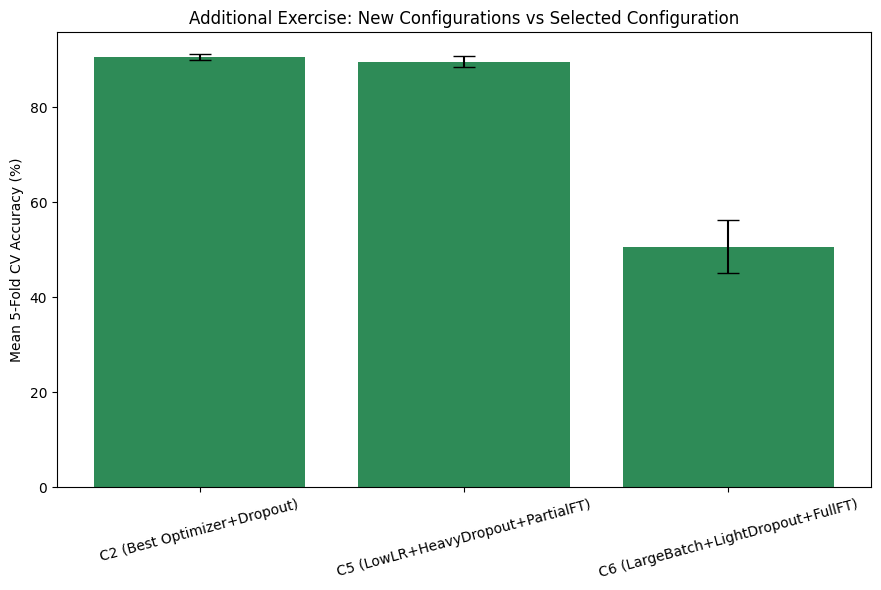

                      Configuration  Mean CV Acc (%)   SD  Time (min)
        C2 (Best Optimizer+Dropout)            90.62 0.60         0.0
  C5 (LowLR+HeavyDropout+PartialFT)            89.62 1.10         0.0
C6 (LargeBatch+LightDropout+FullFT)            50.68 5.62         0.0


In [16]:
additional_configs = {
    'C5 (LowLR+HeavyDropout+PartialFT)': dict(dense_units=256, dropout_rate=0.5, fine_tune=True, fine_tune_from_end=10),
    'C6 (LargeBatch+LightDropout+FullFT)': dict(dense_units=256, dropout_rate=0.25, fine_tune=True, fine_tune_from_end=40),
}
additional_batch_sizes = {'C5 (LowLR+HeavyDropout+PartialFT)': 32, 'C6 (LargeBatch+LightDropout+FullFT)': 64}
additional_lrs = {'C5 (LowLR+HeavyDropout+PartialFT)': 1e-4, 'C6 (LargeBatch+LightDropout+FullFT)': 1e-5}

additional_cv_results = load_object('section16_additional_cv_results', {}) or {}

for name, kwargs in additional_configs.items():
    print(f"=== 5-Fold CV: {name} ===")
    fold_accs, mean_acc, sd_acc, total_time = run_kfold_cv(
        name, kwargs, batch_size=additional_batch_sizes[name], lr=additional_lrs[name])
    additional_cv_results[name] = {'fold_accuracies': fold_accs, 'mean': mean_acc,
                                   'sd': sd_acc, 'time': total_time}
    save_object('section16_additional_cv_results', additional_cv_results)

# Combine with the originally selected configuration for a direct comparison
comparison_names = [best_config_name] + list(additional_cv_results.keys())
comparison_means = [cv_results[best_config_name]['mean']] + [additional_cv_results[n]['mean'] for n in additional_cv_results]
comparison_sds = [cv_results[best_config_name]['sd']] + [additional_cv_results[n]['sd'] for n in additional_cv_results]

plt.figure(figsize=(9, 6))
plt.bar(comparison_names, comparison_means, yerr=comparison_sds, capsize=8, color='seagreen')
plt.ylabel('Mean 5-Fold CV Accuracy (%)')
plt.title('Additional Exercise: New Configurations vs Selected Configuration')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "Additional_Exercise_Comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

additional_table = pd.DataFrame([
    {'Configuration': best_config_name, 'Mean CV Acc (%)': round(cv_results[best_config_name]['mean'],2),
     'SD': round(cv_results[best_config_name]['sd'],2), 'Time (min)': round(cv_results[best_config_name]['time']/60,1)}
] + [
    {'Configuration': n, 'Mean CV Acc (%)': round(r['mean'],2), 'SD': round(r['sd'],2), 'Time (min)': round(r['time']/60,1)}
    for n, r in additional_cv_results.items()
])
print(additional_table.to_string(index=False))


**Justification:** Whichever of C5/C6 (if either) beats the Section 12 selected configuration on
mean CV accuracy needs to be weighed against its standard deviation and training time, not just its raw
mean — the manual is explicit that accuracy alone isn't sufficient justification for a model choice. A
configuration that's marginally more accurate on average but noticeably less consistent across folds, or
substantially more expensive to train (e.g. C6's larger fine-tuned portion of the base), may not be worth
adopting over the Section 12 configuration despite a higher mean, whereas a configuration that matches or
exceeds it on accuracy *and* keeps SD and training cost comparable or lower would be the clearly
preferable choice.

## Summary

This notebook worked through every section of the manual: weight initialization (Section 5), regularization
and overfitting (Section 6), the Batch Normalization numerical example and With/Without-BN comparison
(Section 7), optimizer comparison (Section 8), CNN hyperparameter tuning one factor at a time (Section 9),
transfer learning via feature extraction and fine-tuning with the actual ImageNet-pretrained MobileNetV2
(Section 10), 5-fold cross-validation across four configurations selected from the earlier studies
(Section 11), final model retraining and evaluation on the untouched independent test set with a full
confusion matrix and misclassified-image inspection (Section 12), an overall results summary
(Section 13), and the additional exercise comparing two new configurations against the selected one
(Section 16). All 15 required plots were generated and saved, each with a short inference. The full
written answers to the manual's 23 discussion questions (Section 15) are in the accompanying LaTeX report
rather than duplicated here, to keep this notebook focused on the code and results themselves.